# Imports

In [1]:
import os


os.chdir("../")

In [2]:
from utils import (hyperas_path, init, load_cifar10, get_model, 
                get_callbacks, plot_history, extract_features, 
                show_img, continually_learn, save_samples, 
                load_samples, CL_plot)


TUNED_CNN_MODEL_PATH = os.path.join(hyperas_path, "cifar10_cnn_model_01.h5")
TUNED_DNN_MODEL_PATH = os.path.join(hyperas_path, "cifar10_dnn_model_00.h5")

CLASS_NUM = 10
BATCH_SIZE = 128
EPOCHS = 100

init()

# Demonstrating the usual 10-class training setting

## Hyperparameter-tuned CNN Model

In [11]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(preprocess="min-max")

(40000, 32, 32, 3) (40000, 1)
(10000, 32, 32, 3) (10000, 1)
(10000, 32, 32, 3) (10000, 1)
---0
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]

---1
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]

---2
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]



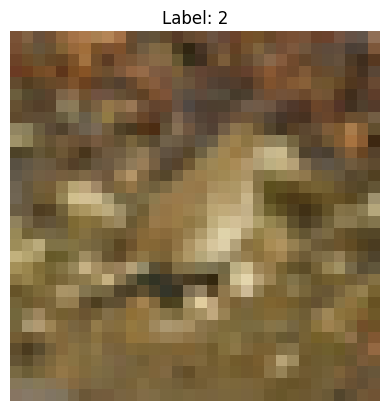

In [12]:
index = 1_000
show_img(x_train[index], y_train[index])

In [13]:
model = get_model(CLASS_NUM, model_type="hp-tuned", model_path=TUNED_CNN_MODEL_PATH) # , use_loaded_opt=True

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_6 (Sequential)   (None, 16, 16, 64)        9664      
                                                                 
 sequential_7 (Sequential)   (None, 8, 8, 128)         222208    
                                                                 
 sequential_8 (Sequential)   (None, 4, 4, 128)         295936    
                                                                 
 sequential_9 (Sequential)   (None, 2, 2, 256)         295936    
                                                                 
 global_average_pooling2d_1   (None, 256)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                        

In [13]:
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 11s 23ms/step - loss: 1.4033 - accuracy: 0.4966 - val_loss: 2.6316 - val_accuracy: 0.2719
Epoch 2/100
313/313 [==============================] - 7s 21ms/step - loss: 0.9531 - accuracy: 0.6611 - val_loss: 1.5426 - val_accuracy: 0.5000
Epoch 3/100
313/313 [==============================] - 7s 21ms/step - loss: 0.7570 - accuracy: 0.7338 - val_loss: 1.0097 - val_accuracy: 0.6537
Epoch 4/100
313/313 [==============================] - 7s 21ms/step - loss: 0.6215 - accuracy: 0.7837 - val_loss: 0.9815 - val_accuracy: 0.6718
Epoch 5/100
313/313 [==============================] - 7s 21ms/step - loss: 0.5252 - accuracy: 0.8175 - val_loss: 0.9472 - val_accuracy: 0.6873
Epoch 6/100
313/313 [==============================] - 7s 21ms/step - loss: 0.4368 - accuracy: 0.8478 - val_loss: 0.9513 - val_accuracy: 0.6909
Epoch 7/100
313/313 [==============================] - 7s 21ms/step - loss: 0.3714 - accuracy: 0.8706 - val_loss: 1.0242 - val_accuracy

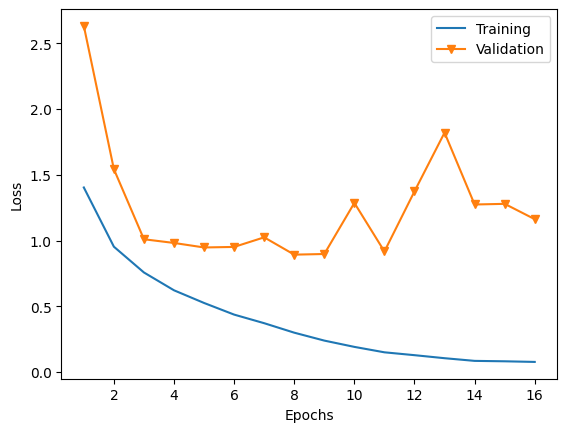

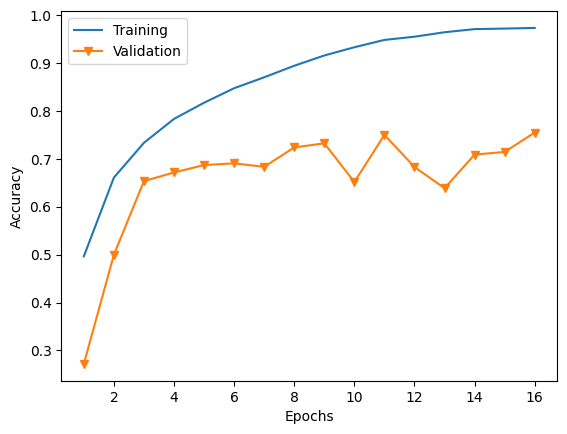

313/313 [==============================] - 1s 4ms/step - loss: 0.9191 - accuracy: 0.7528


[0.9191192388534546, 0.7527999877929688]

In [14]:
plot_history(history)

model.evaluate(x_test, y_test)

## Hyperparameter-tuned DNN Model

In [3]:
feature_train, y_train, feature_val, y_val, feature_test, y_test = load_cifar10(return_features=True, verbose=0)

In [4]:
model = get_model(CLASS_NUM, model_type="hp-tuned", model_path=TUNED_DNN_MODEL_PATH, use_loaded_opt=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization_353 (Ba  (None, 2048)             8192      
 tchNormalization)                                               
                                                                 
 sequential_336 (Sequential)  (None, 256)              525312    
                                                                 
 sequential_337 (Sequential)  (None, 128)              33280     
                                                                 
 dropout_488 (Dropout)       (None, 128)               0         
                                                                 
 dense (Dense)               (None, 10)                1290      
                                                                 
Total params: 568,074
Trainable params: 563,210
Non-trainable params: 4,864
______________________________________________

In [5]:
history = model.fit(
    feature_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(feature_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 5s 10ms/step - loss: 0.4893 - accuracy: 0.8389 - val_loss: 0.3627 - val_accuracy: 0.8747
Epoch 2/100
313/313 [==============================] - 3s 10ms/step - loss: 0.3550 - accuracy: 0.8787 - val_loss: 0.3196 - val_accuracy: 0.8918
Epoch 3/100
313/313 [==============================] - 3s 11ms/step - loss: 0.2999 - accuracy: 0.8974 - val_loss: 0.3151 - val_accuracy: 0.8954
Epoch 4/100
313/313 [==============================] - 3s 11ms/step - loss: 0.2633 - accuracy: 0.9109 - val_loss: 0.3165 - val_accuracy: 0.8979
Epoch 5/100
313/313 [==============================] - 3s 11ms/step - loss: 0.2351 - accuracy: 0.9194 - val_loss: 0.3166 - val_accuracy: 0.8984
Epoch 6/100
313/313 [==============================] - 3s 10ms/step - loss: 0.2150 - accuracy: 0.9262 - val_loss: 0.3081 - val_accuracy: 0.9009
Epoch 7/100
313/313 [==============================] - 3s 10ms/step - loss: 0.1921 - accuracy: 0.9342 - val_loss: 0.3170 - val_accuracy:

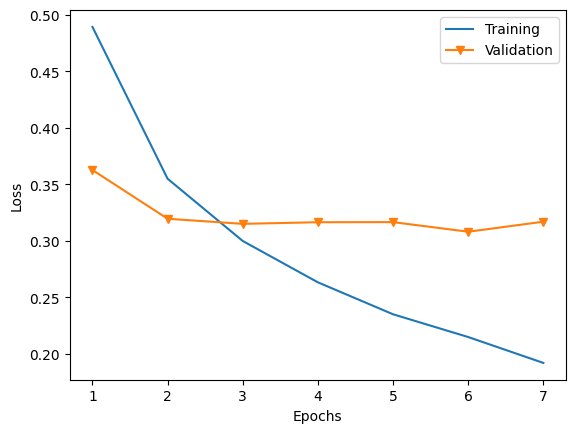

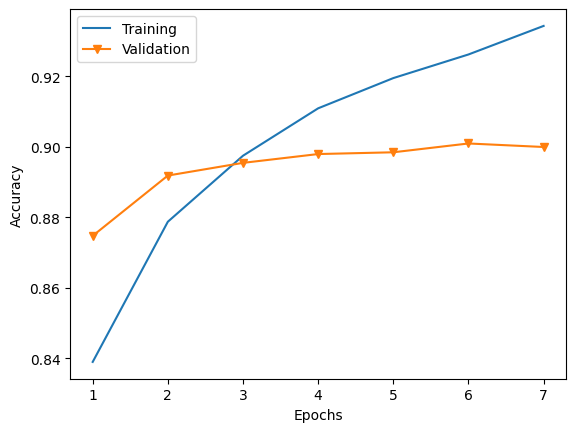

313/313 [==============================] - 1s 3ms/step - loss: 0.3341 - accuracy: 0.8890


[0.33412042260169983, 0.8889999985694885]

In [6]:
plot_history(history)

model.evaluate(feature_test, y_test)

## Transfer Learning with the pre-trained Xception Model

In [11]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(verbose=0)

In [12]:
feature_train, feature_val, feature_test = extract_features(
    [x_train, x_val, x_test], 
    batch_size=BATCH_SIZE, 
    file_name="./data/cifar10_xception_gavgpooled_features_train_val_test"
)

79/79 [==============================] - 73s 940ms/step


In [ ]:
feature_train, feature_val, feature_test = load_samples(
    "./data/cifar10_xception_gavgpooled_features_train_val_test", 
    ".npy"
)

In [13]:
model = get_model(CLASS_NUM, model_type="DNN", dropout_rate=0.5)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_1 (Dropout)         (None, 2048)              0         
                                                                 
 dense_1 (Dense)             (None, 10)                20490     
                                                                 
Total params: 20,490
Trainable params: 20,490
Non-trainable params: 0
_________________________________________________________________


In [14]:
history = model.fit(
    feature_train, y_train,
    epochs=EPOCHS,
    validation_data=(feature_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
1250/1250 [==============================] - 5s 3ms/step - loss: 0.5361 - accuracy: 0.8285 - val_loss: 0.3863 - val_accuracy: 0.8721
Epoch 2/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3932 - accuracy: 0.8654 - val_loss: 0.3503 - val_accuracy: 0.8823
Epoch 3/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3732 - accuracy: 0.8723 - val_loss: 0.3413 - val_accuracy: 0.8801
Epoch 4/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3636 - accuracy: 0.8747 - val_loss: 0.3416 - val_accuracy: 0.8793
Epoch 5/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3554 - accuracy: 0.8781 - val_loss: 0.3305 - val_accuracy: 0.8827
Epoch 6/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3528 - accuracy: 0.8779 - val_loss: 0.3327 - val_accuracy: 0.8833
Epoch 7/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3501 - accuracy: 0.8789 - val_loss: 0.3277 - val_ac

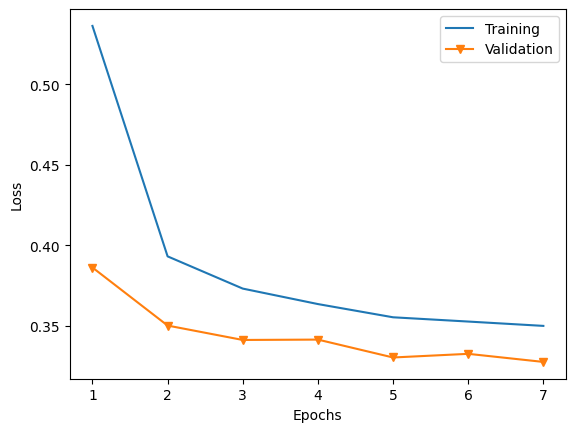

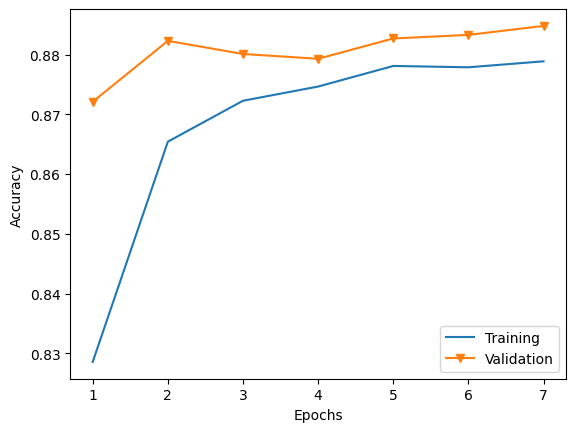

313/313 [==============================] - 1s 3ms/step - loss: 0.3587 - accuracy: 0.8788


[0.35869887471199036, 0.8787999749183655]

In [15]:
plot_history(history)

model.evaluate(feature_test, y_test)

## Fine-tuning the pre-trained Xception Model

In [9]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(verbose=0)

In [12]:
model = get_model(CLASS_NUM, model_type="pretrained", num_last_not_frozen=12, dropout_rate=0.50)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resize (Lambda)             (None, 299, 299, 3)       0         
                                                                 
 xception_preprocess (Lambda  (None, 299, 299, 3)      0         
 )                                                               
                                                                 
 xception (Functional)       (None, 10, 10, 2048)      20861480  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 10)                2

In [13]:
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 804s 3s/step - loss: 0.3157 - accuracy: 0.8951 - val_loss: 0.2794 - val_accuracy: 0.9133
Epoch 2/100
313/313 [==============================] - 833s 3s/step - loss: 0.1676 - accuracy: 0.9423 - val_loss: 0.2581 - val_accuracy: 0.9157
Epoch 3/100
313/313 [==============================] - 666s 2s/step - loss: 0.1059 - accuracy: 0.9624 - val_loss: 0.2893 - val_accuracy: 0.9163
Epoch 4/100
313/313 [==============================] - 495s 2s/step - loss: 0.0650 - accuracy: 0.9777 - val_loss: 0.3214 - val_accuracy: 0.9159
Epoch 5/100
313/313 [==============================] - 828s 3s/step - loss: 0.0417 - accuracy: 0.9857 - val_loss: 0.2883 - val_accuracy: 0.9222
Epoch 6/100
313/313 [==============================] - 871s 3s/step - loss: 0.0360 - accuracy: 0.9877 - val_loss: 0.3195 - val_accuracy: 0.9259
Epoch 7/100
313/313 [==============================] - 681s 2s/step - loss: 0.0318 - accuracy: 0.9886 - val_loss: 0.3426 - val_accuracy:

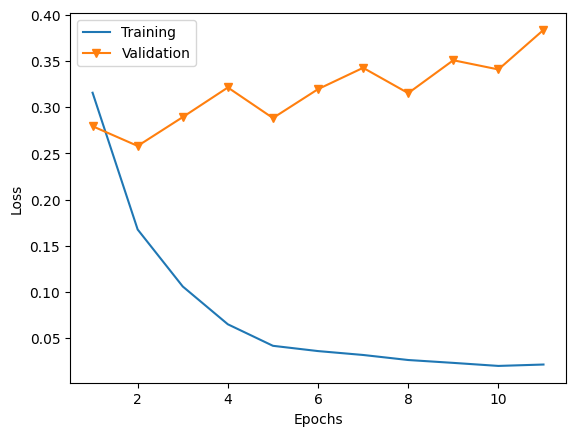

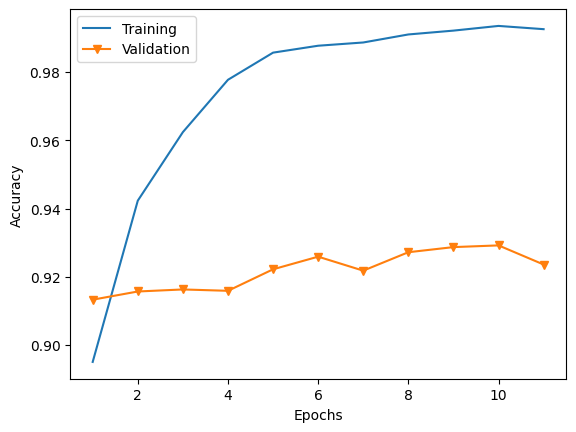

313/313 [==============================] - 159s 488ms/step - loss: 0.3389 - accuracy: 0.9225


[0.338937371969223, 0.9225000143051147]

In [14]:
plot_history(history)

model.evaluate(x_test, y_test)

# Continual Learning

## Continually adding classes to different models

### CNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 8.
Epoch 13: early stopping


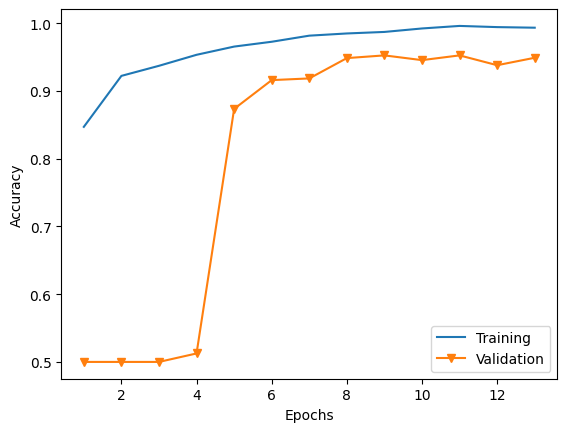

63/63 [==============================] - 0s 4ms/step
              precision    recall  f1-score   support

           0     0.9734    0.9160    0.9438      1000
           1     0.9207    0.9750    0.9471      1000

    accuracy                         0.9455      2000
   macro avg     0.9471    0.9455    0.9455      2000
weighted avg     0.9471    0.9455    0.9455      2000



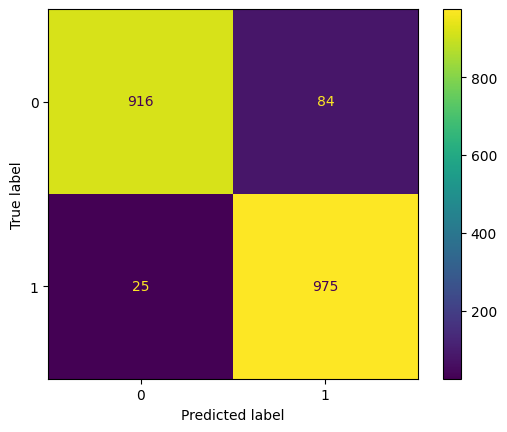

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


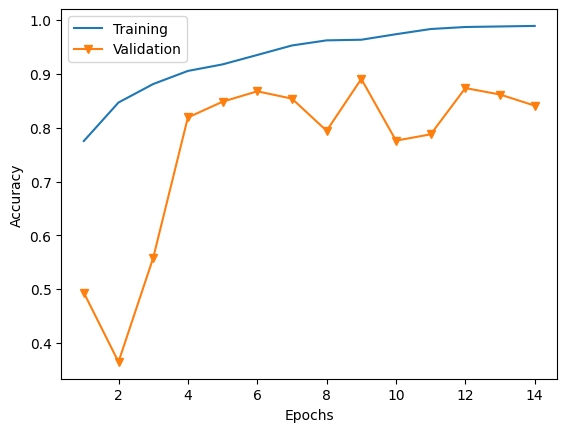

94/94 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.8442    0.8940    0.8684      1000
           1     0.9348    0.9600    0.9472      1000
           2     0.9168    0.8380    0.8757      1000

    accuracy                         0.8973      3000
   macro avg     0.8986    0.8973    0.8971      3000
weighted avg     0.8986    0.8973    0.8971      3000



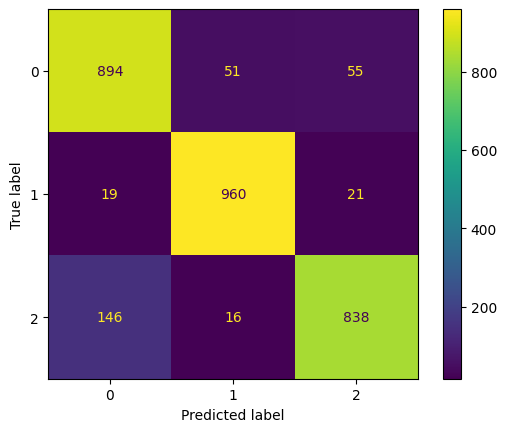

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


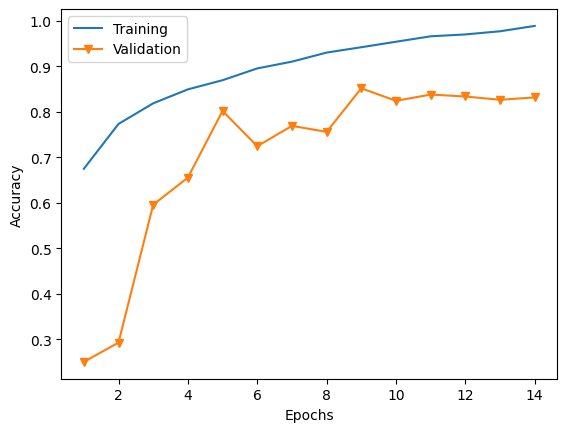

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8934    0.8380    0.8648      1000
           1     0.8724    0.9780    0.9222      1000
           2     0.8348    0.7530    0.7918      1000
           3     0.7950    0.8260    0.8102      1000

    accuracy                         0.8488      4000
   macro avg     0.8489    0.8488    0.8473      4000
weighted avg     0.8489    0.8488    0.8473      4000



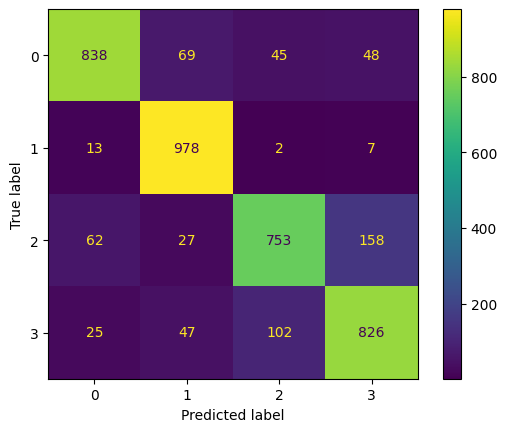

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 8.
Epoch 13: early stopping


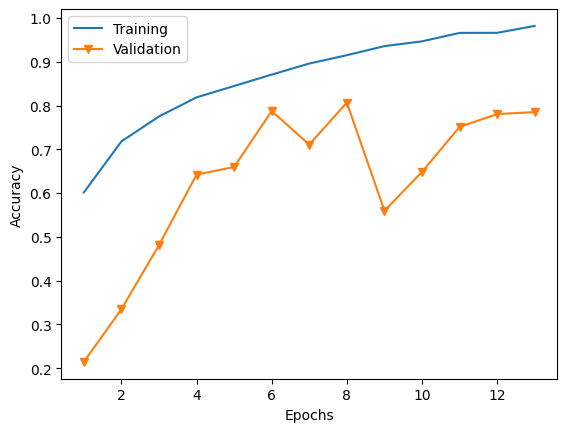

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8122    0.9040    0.8557      1000
           1     0.8994    0.9660    0.9315      1000
           2     0.6875    0.7590    0.7215      1000
           3     0.9003    0.5330    0.6696      1000
           4     0.7386    0.8250    0.7794      1000

    accuracy                         0.7974      5000
   macro avg     0.8076    0.7974    0.7915      5000
weighted avg     0.8076    0.7974    0.7915      5000



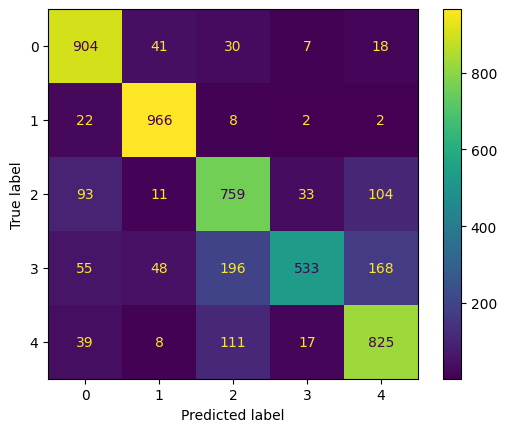

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 18.
Epoch 23: early stopping


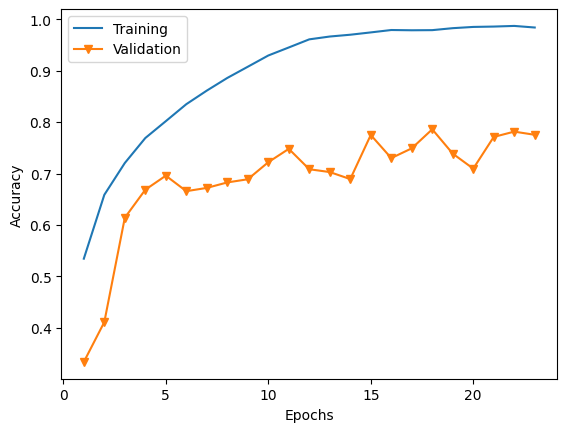

188/188 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8808    0.8500    0.8651      1000
           1     0.9706    0.9260    0.9478      1000
           2     0.7786    0.7070    0.7411      1000
           3     0.6600    0.6580    0.6590      1000
           4     0.7839    0.7980    0.7909      1000
           5     0.6675    0.7730    0.7164      1000

    accuracy                         0.7853      6000
   macro avg     0.7903    0.7853    0.7867      6000
weighted avg     0.7903    0.7853    0.7867      6000



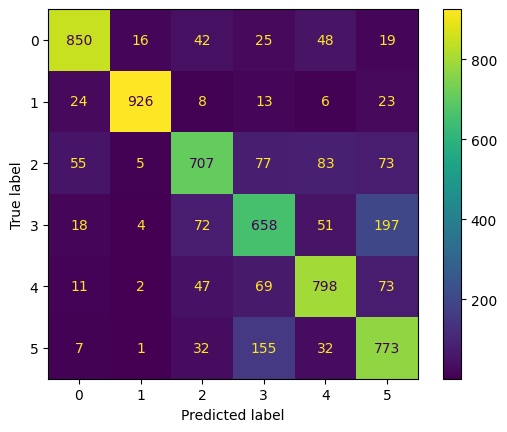

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 12.
Epoch 17: early stopping


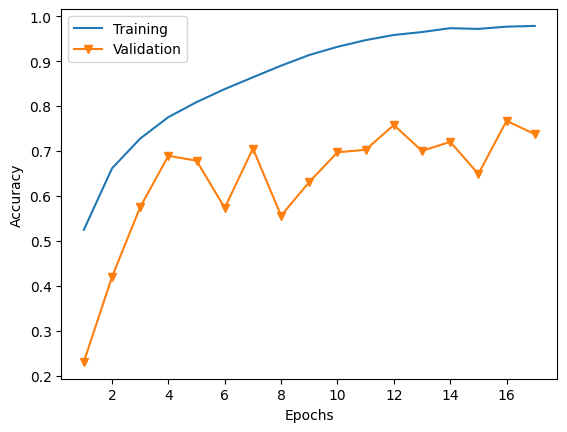

219/219 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8544    0.8450    0.8497      1000
           1     0.8727    0.9670    0.9175      1000
           2     0.7430    0.6620    0.7002      1000
           3     0.5473    0.7410    0.6296      1000
           4     0.6938    0.8450    0.7619      1000
           5     0.9065    0.4170    0.5712      1000
           6     0.8357    0.8190    0.8273      1000

    accuracy                         0.7566      7000
   macro avg     0.7791    0.7566    0.7510      7000
weighted avg     0.7791    0.7566    0.7510      7000



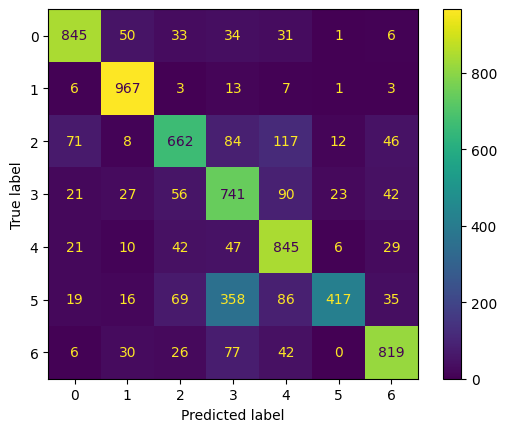

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 10.
Epoch 15: early stopping


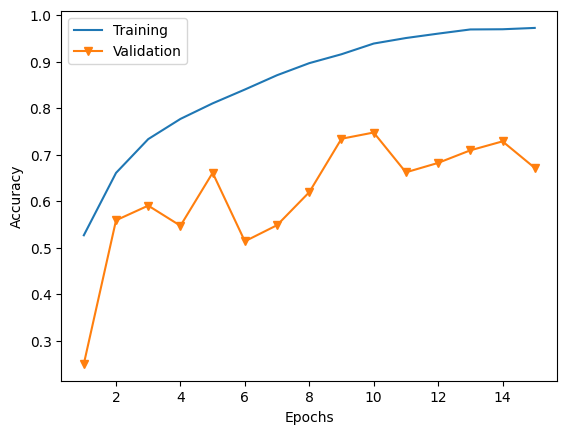

250/250 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.7849    0.8940    0.8359      1000
           1     0.9646    0.9000    0.9312      1000
           2     0.7560    0.6350    0.6902      1000
           3     0.5924    0.6540    0.6217      1000
           4     0.5265    0.9030    0.6652      1000
           5     0.8944    0.3980    0.5509      1000
           6     0.8335    0.8110    0.8221      1000
           7     0.8508    0.7240    0.7823      1000

    accuracy                         0.7399      8000
   macro avg     0.7754    0.7399    0.7374      8000
weighted avg     0.7754    0.7399    0.7374      8000



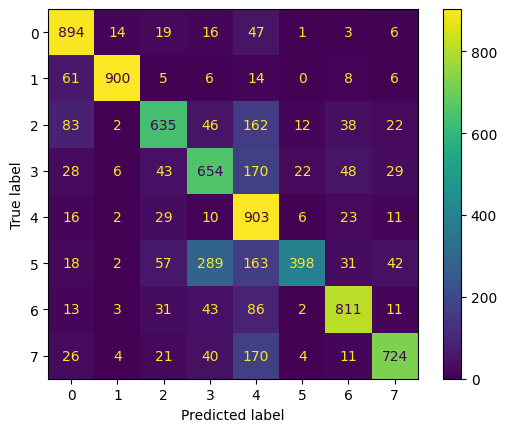

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 12.
Epoch 17: early stopping


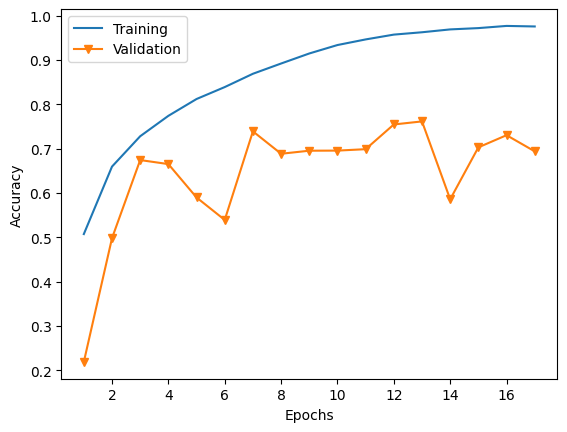

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.7832    0.8200    0.8012      1000
           1     0.8299    0.9560    0.8885      1000
           2     0.6919    0.6400    0.6649      1000
           3     0.7491    0.4060    0.5266      1000
           4     0.5614    0.8820    0.6861      1000
           5     0.7284    0.6410    0.6819      1000
           6     0.9010    0.7280    0.8053      1000
           7     0.7372    0.8190    0.7759      1000
           8     0.8631    0.8320    0.8473      1000

    accuracy                         0.7471      9000
   macro avg     0.7606    0.7471    0.7420      9000
weighted avg     0.7606    0.7471    0.7420      9000



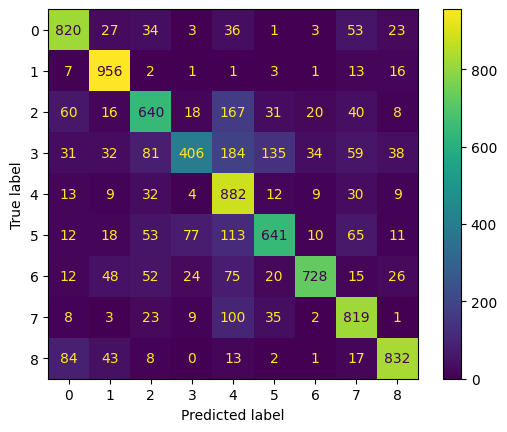

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 7.
Epoch 12: early stopping


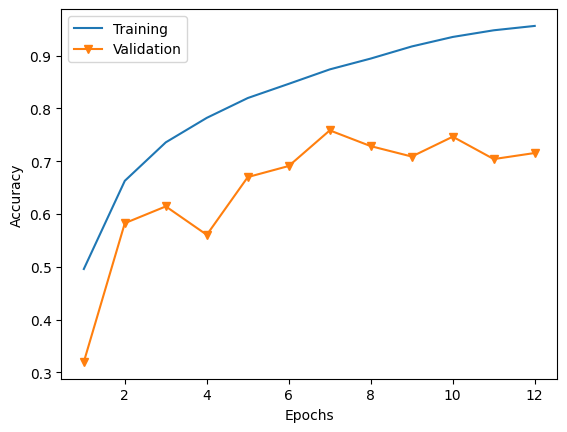

313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.6634    0.8710    0.7531      1000
           1     0.8807    0.8640    0.8723      1000
           2     0.7178    0.6740    0.6952      1000
           3     0.6473    0.5580    0.5994      1000
           4     0.6125    0.7730    0.6835      1000
           5     0.7561    0.6510    0.6996      1000
           6     0.9671    0.5290    0.6839      1000
           7     0.7109    0.8680    0.7816      1000
           8     0.8222    0.9020    0.8603      1000
           9     0.8800    0.8070    0.8419      1000

    accuracy                         0.7497     10000
   macro avg     0.7658    0.7497    0.7471     10000
weighted avg     0.7658    0.7497    0.7471     10000



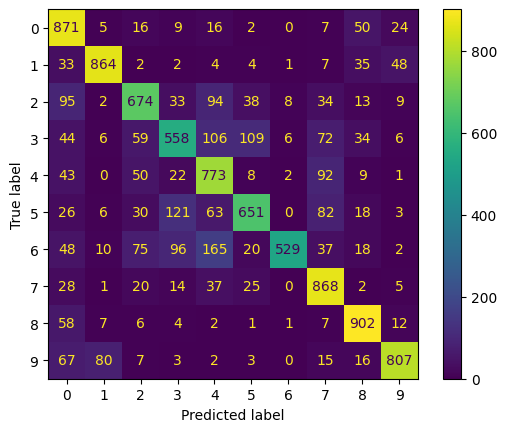

---------------------------------------------------------------------------



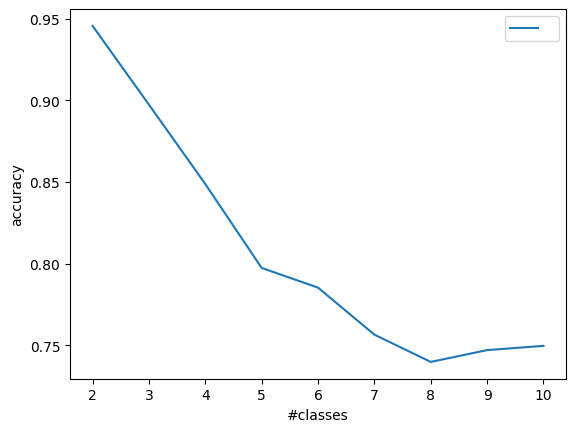

In [4]:
acc_list1 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    keep_same_model=False, 
    remove_prev_classes=False, 
    tuned_model_path=TUNED_CNN_MODEL_PATH, 
    preprocess="min-max",
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


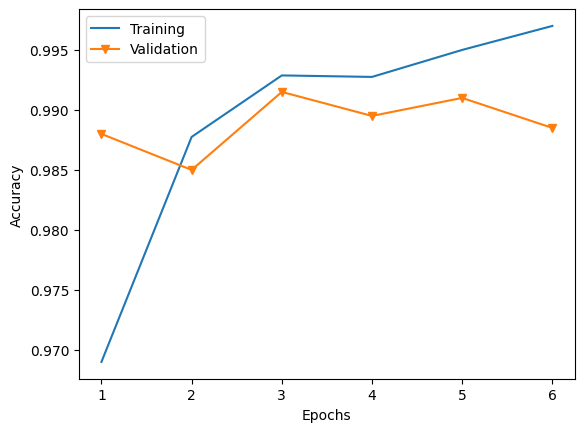

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9909    0.9850    0.9880      1000
           1     0.9851    0.9910    0.9880      1000

    accuracy                         0.9880      2000
   macro avg     0.9880    0.9880    0.9880      2000
weighted avg     0.9880    0.9880    0.9880      2000



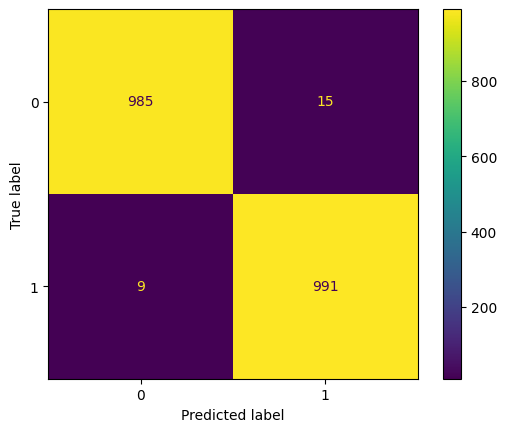

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


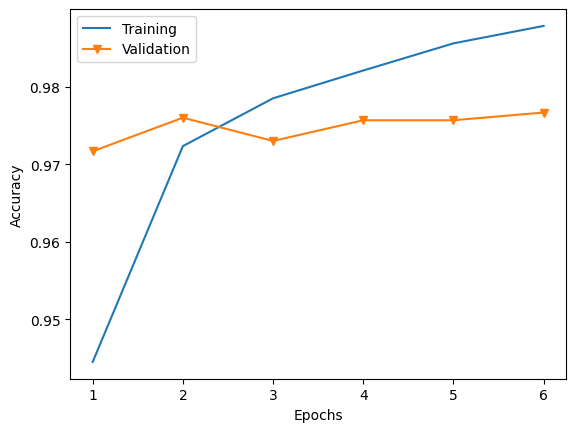

94/94 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.9403    0.9760    0.9578      1000
           1     0.9939    0.9780    0.9859      1000
           2     0.9806    0.9590    0.9697      1000

    accuracy                         0.9710      3000
   macro avg     0.9716    0.9710    0.9711      3000
weighted avg     0.9716    0.9710    0.9711      3000



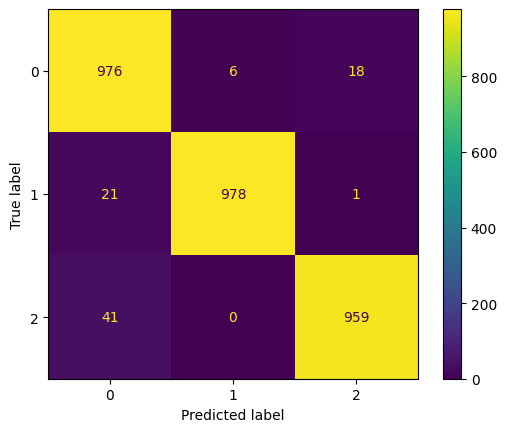

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


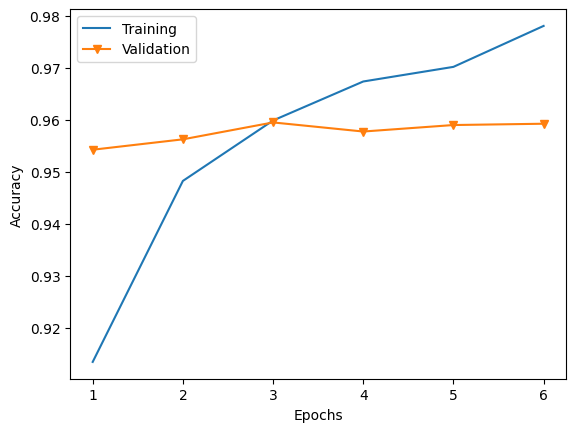

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9435    0.9510    0.9472      1000
           1     0.9761    0.9790    0.9775      1000
           2     0.9306    0.8990    0.9145      1000
           3     0.9120    0.9330    0.9224      1000

    accuracy                         0.9405      4000
   macro avg     0.9405    0.9405    0.9404      4000
weighted avg     0.9405    0.9405    0.9404      4000



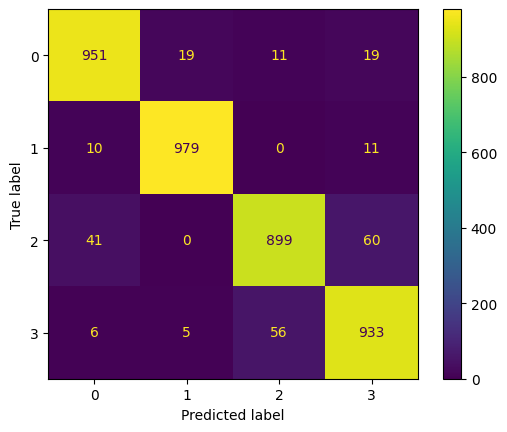

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 6.
Epoch 11: early stopping


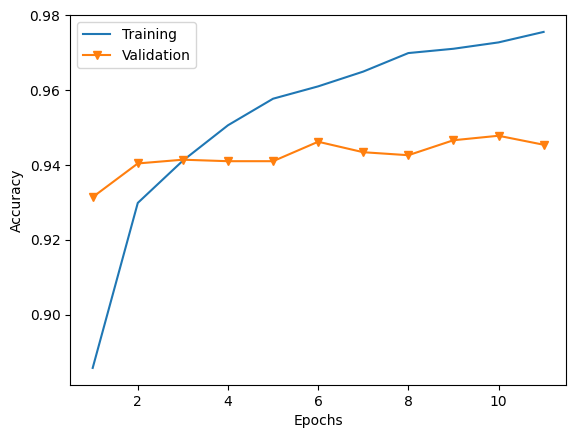

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9541    0.9560    0.9550      1000
           1     0.9868    0.9750    0.9809      1000
           2     0.9240    0.8870    0.9051      1000
           3     0.8862    0.9190    0.9023      1000
           4     0.9121    0.9240    0.9180      1000

    accuracy                         0.9322      5000
   macro avg     0.9326    0.9322    0.9323      5000
weighted avg     0.9326    0.9322    0.9323      5000



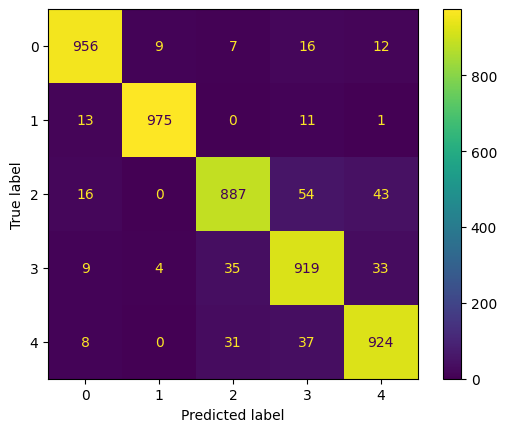

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


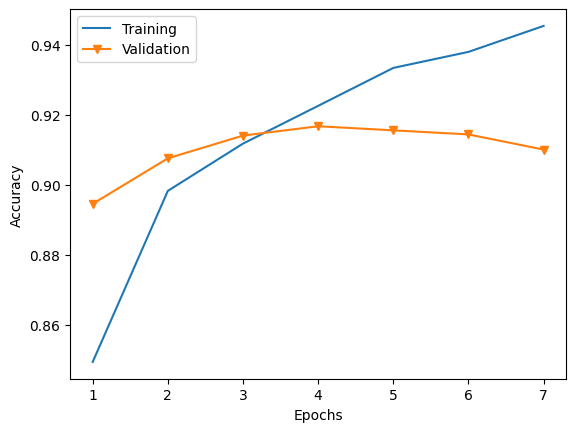

188/188 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9386    0.9630    0.9506      1000
           1     0.9899    0.9760    0.9829      1000
           2     0.9459    0.8210    0.8790      1000
           3     0.7968    0.8470    0.8211      1000
           4     0.8860    0.9330    0.9089      1000
           5     0.8596    0.8630    0.8613      1000

    accuracy                         0.9005      6000
   macro avg     0.9028    0.9005    0.9006      6000
weighted avg     0.9028    0.9005    0.9006      6000



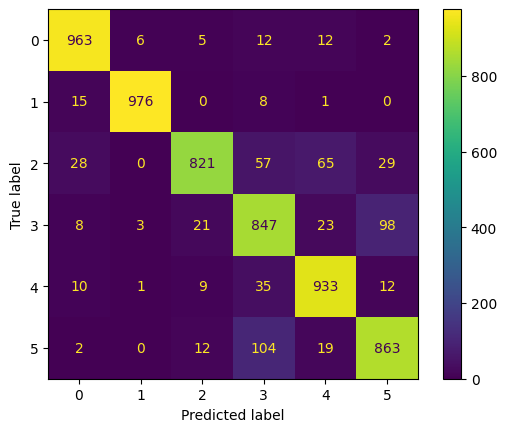

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


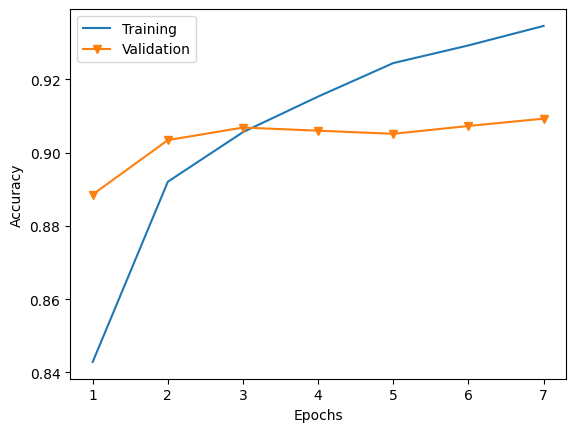

219/219 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9556    0.9460    0.9508      1000
           1     0.9869    0.9820    0.9845      1000
           2     0.9074    0.8530    0.8794      1000
           3     0.7507    0.8520    0.7981      1000
           4     0.8775    0.9240    0.9001      1000
           5     0.9171    0.7970    0.8529      1000
           6     0.8969    0.9130    0.9049      1000

    accuracy                         0.8953      7000
   macro avg     0.8989    0.8953    0.8958      7000
weighted avg     0.8989    0.8953    0.8958      7000



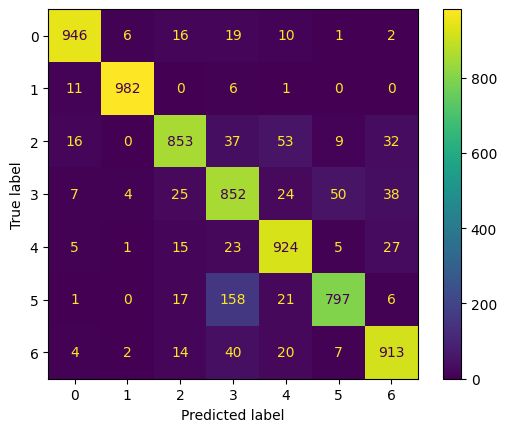

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


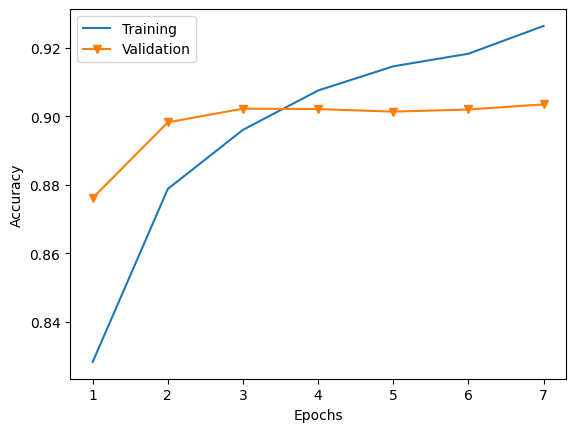

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9263    0.9550    0.9404      1000
           1     0.9879    0.9790    0.9834      1000
           2     0.9177    0.8360    0.8749      1000
           3     0.7417    0.8530    0.7935      1000
           4     0.8456    0.8870    0.8658      1000
           5     0.9033    0.7940    0.8451      1000
           6     0.9116    0.9080    0.9098      1000
           7     0.9053    0.8990    0.9022      1000

    accuracy                         0.8889      8000
   macro avg     0.8924    0.8889    0.8894      8000
weighted avg     0.8924    0.8889    0.8894      8000



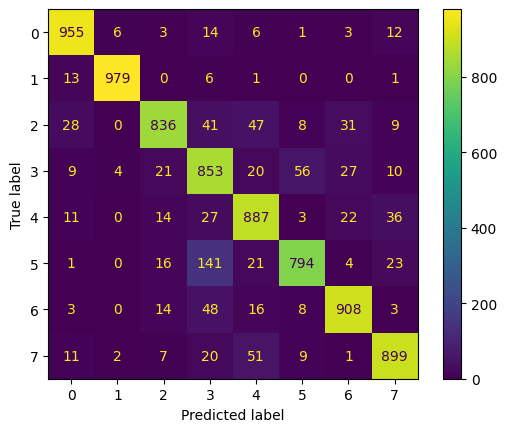

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


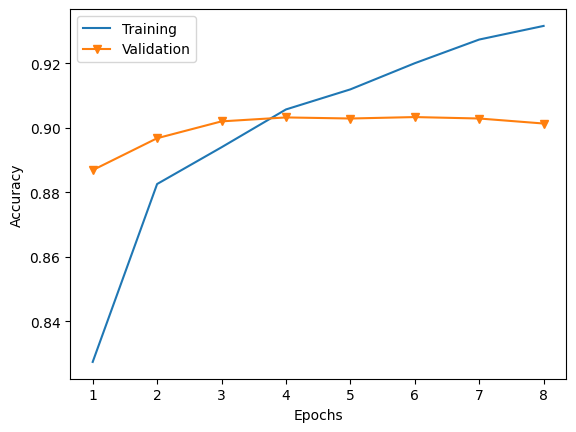

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9259    0.9000    0.9128      1000
           1     0.9750    0.9760    0.9755      1000
           2     0.9205    0.8340    0.8751      1000
           3     0.7811    0.8030    0.7919      1000
           4     0.8346    0.9030    0.8674      1000
           5     0.8712    0.8390    0.8548      1000
           6     0.8924    0.9120    0.9021      1000
           7     0.9127    0.8990    0.9058      1000
           8     0.9251    0.9630    0.9437      1000

    accuracy                         0.8921      9000
   macro avg     0.8932    0.8921    0.8921      9000
weighted avg     0.8932    0.8921    0.8921      9000



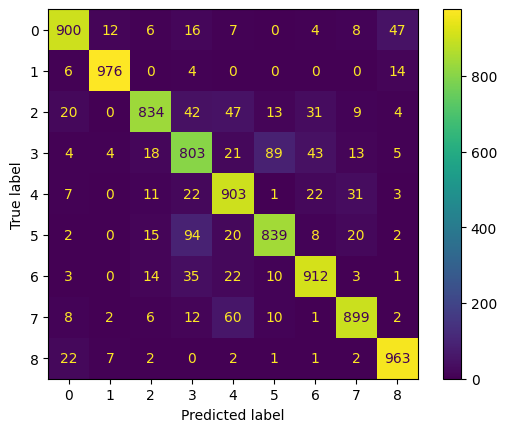

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


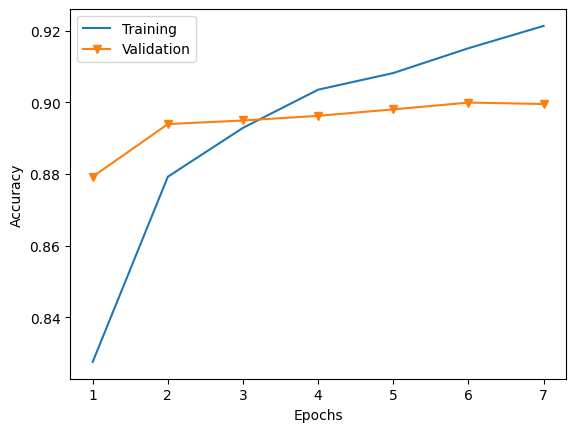

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8880    0.9120    0.8999      1000
           1     0.9166    0.9450    0.9306      1000
           2     0.9044    0.8420    0.8721      1000
           3     0.7486    0.8130    0.7795      1000
           4     0.8825    0.8490    0.8654      1000
           5     0.8734    0.8280    0.8501      1000
           6     0.8907    0.9210    0.9056      1000
           7     0.8952    0.9230    0.9089      1000
           8     0.9400    0.9250    0.9325      1000
           9     0.9275    0.8960    0.9115      1000

    accuracy                         0.8854     10000
   macro avg     0.8867    0.8854    0.8856     10000
weighted avg     0.8867    0.8854    0.8856     10000



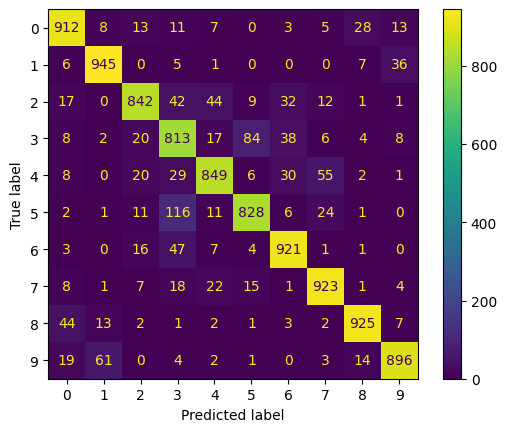

---------------------------------------------------------------------------



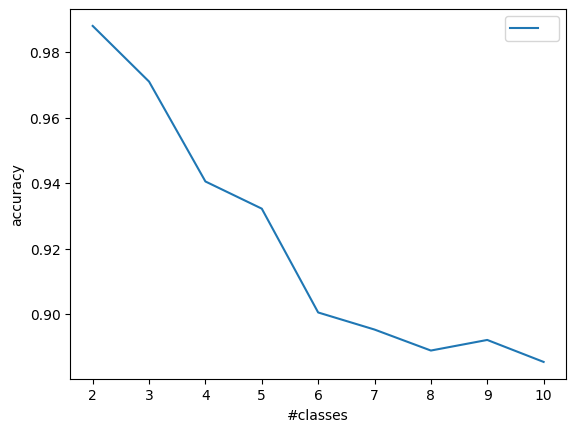

In [5]:
acc_list2 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    keep_same_model=False, 
    remove_prev_classes=False, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

## Continually adding classes to the same model

### CNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 11.
Epoch 16: early stopping


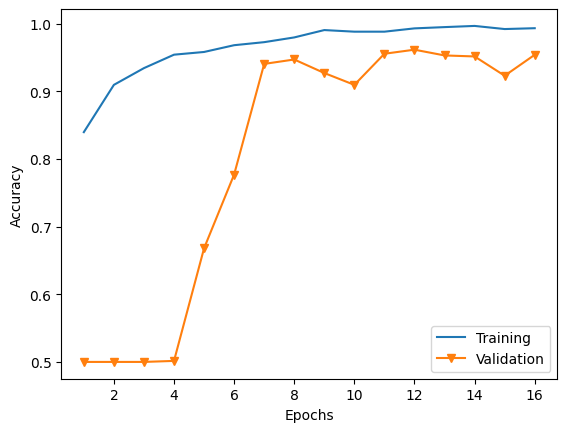

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9738    0.9280    0.9503      1000
           1     0.9312    0.9750    0.9526      1000

    accuracy                         0.9515      2000
   macro avg     0.9525    0.9515    0.9515      2000
weighted avg     0.9525    0.9515    0.9515      2000



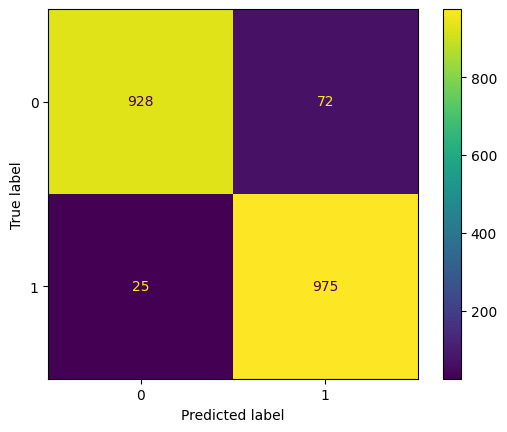

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


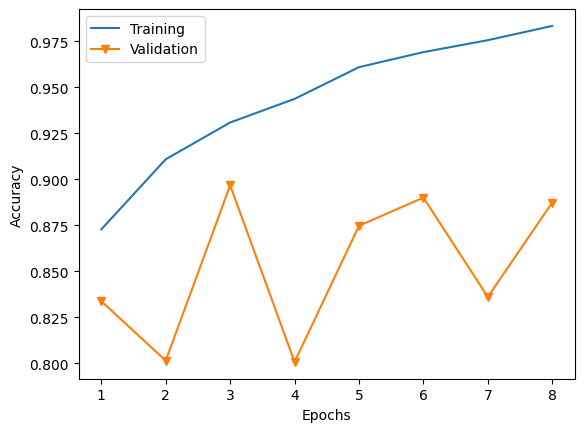

94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8219    0.9090    0.8632      1000
           1     0.9466    0.9400    0.9433      1000
           2     0.9101    0.8200    0.8627      1000

    accuracy                         0.8897      3000
   macro avg     0.8929    0.8897    0.8898      3000
weighted avg     0.8929    0.8897    0.8898      3000



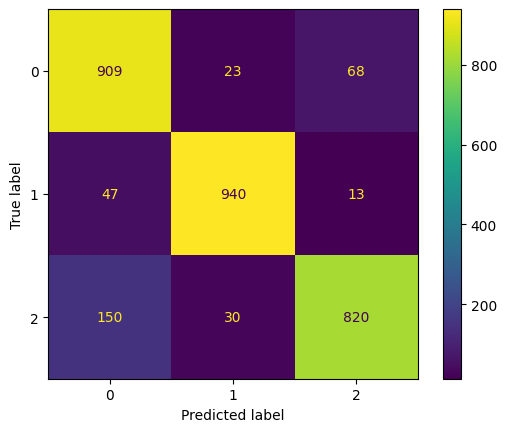

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


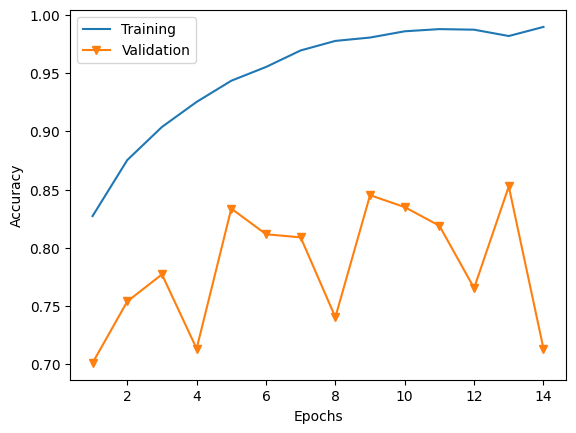

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9027    0.8440    0.8724      1000
           1     0.8780    0.9860    0.9289      1000
           2     0.8571    0.7020    0.7719      1000
           3     0.7774    0.8730    0.8224      1000

    accuracy                         0.8512      4000
   macro avg     0.8538    0.8513    0.8489      4000
weighted avg     0.8538    0.8512    0.8489      4000



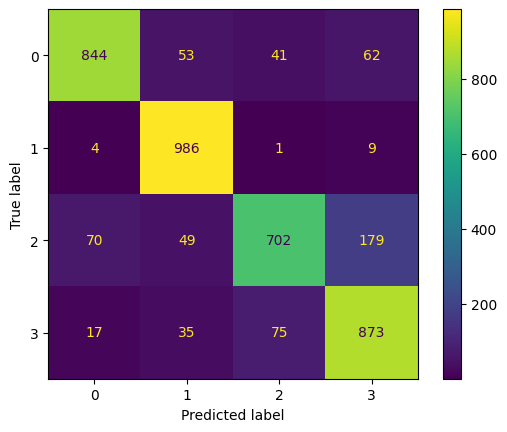

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


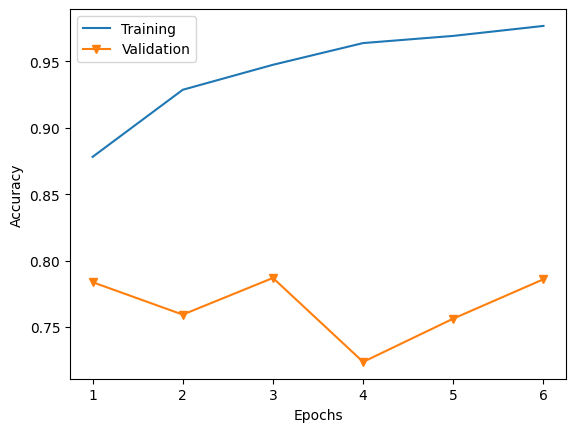

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.7187    0.9400    0.8146      1000
           1     0.9635    0.8970    0.9291      1000
           2     0.8106    0.5820    0.6775      1000
           3     0.7034    0.7920    0.7451      1000
           4     0.7361    0.6750    0.7042      1000

    accuracy                         0.7772      5000
   macro avg     0.7864    0.7772    0.7741      5000
weighted avg     0.7864    0.7772    0.7741      5000



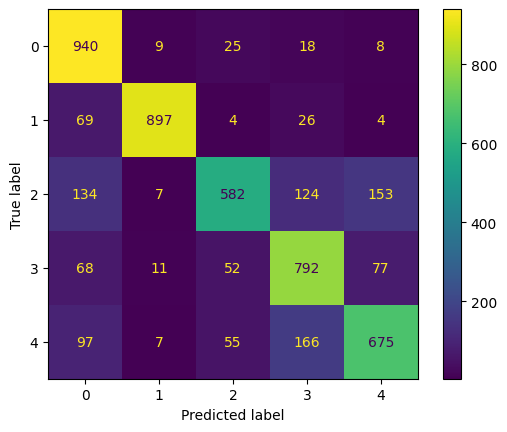

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


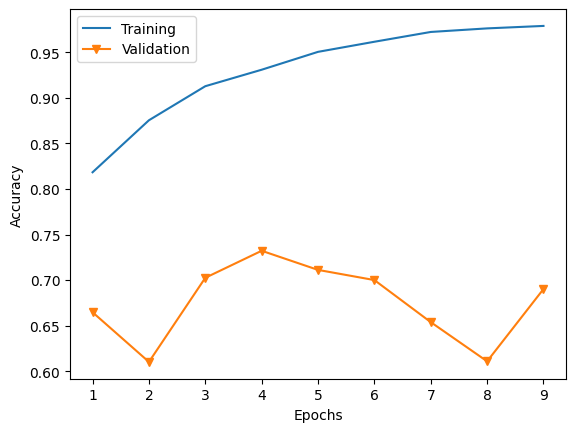

188/188 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.7957    0.8800    0.8357      1000
           1     0.9558    0.9080    0.9313      1000
           2     0.7241    0.5880    0.6490      1000
           3     0.5400    0.7220    0.6179      1000
           4     0.6889    0.7530    0.7195      1000
           5     0.7037    0.4940    0.5805      1000

    accuracy                         0.7242      6000
   macro avg     0.7347    0.7242    0.7223      6000
weighted avg     0.7347    0.7242    0.7223      6000



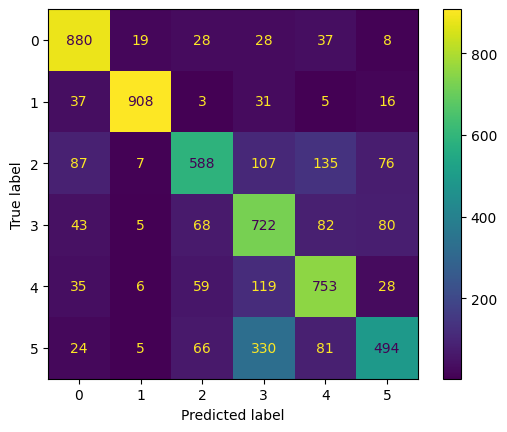

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 5.
Epoch 10: early stopping


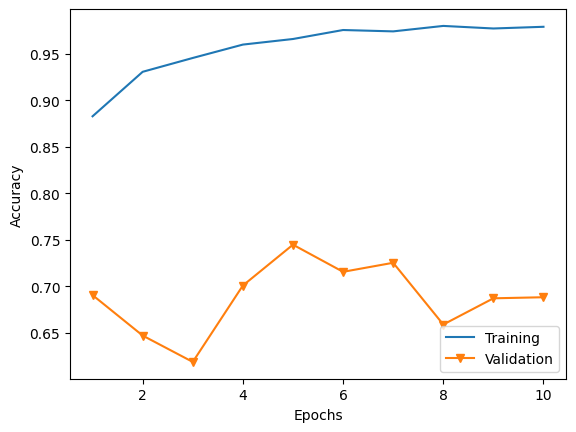

219/219 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8112    0.8810    0.8447      1000
           1     0.8520    0.9730    0.9085      1000
           2     0.7313    0.6750    0.7020      1000
           3     0.6584    0.5590    0.6047      1000
           4     0.8146    0.6020    0.6924      1000
           5     0.6638    0.6830    0.6732      1000
           6     0.6875    0.8470    0.7590      1000

    accuracy                         0.7457      7000
   macro avg     0.7455    0.7457    0.7406      7000
weighted avg     0.7455    0.7457    0.7406      7000



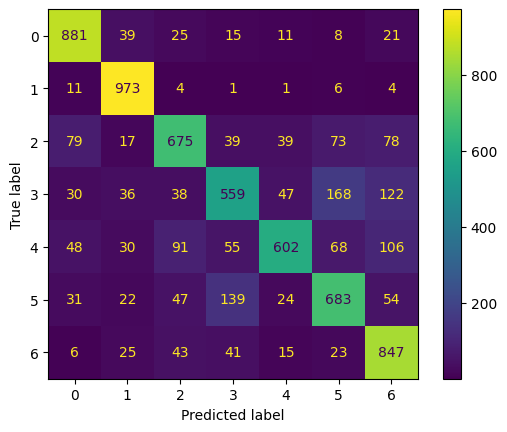

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


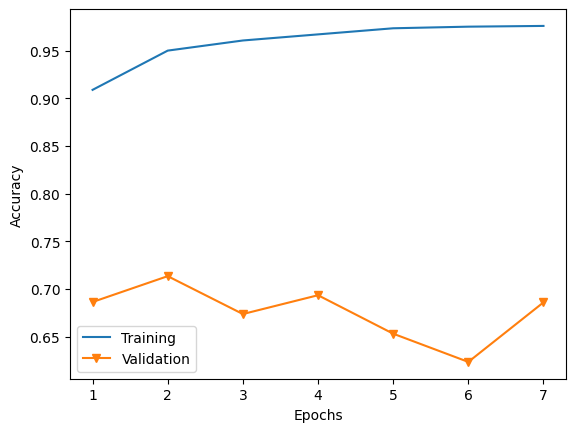

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.7641    0.8650    0.8114      1000
           1     0.9872    0.8490    0.9129      1000
           2     0.5707    0.7510    0.6485      1000
           3     0.5691    0.6010    0.5846      1000
           4     0.8591    0.5000    0.6321      1000
           5     0.6560    0.5970    0.6251      1000
           6     0.7304    0.7560    0.7430      1000
           7     0.6799    0.7540    0.7150      1000

    accuracy                         0.7091      8000
   macro avg     0.7271    0.7091    0.7091      8000
weighted avg     0.7271    0.7091    0.7091      8000



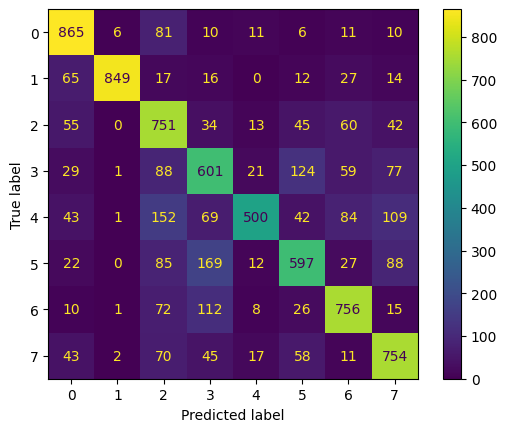

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 6.
Epoch 11: early stopping


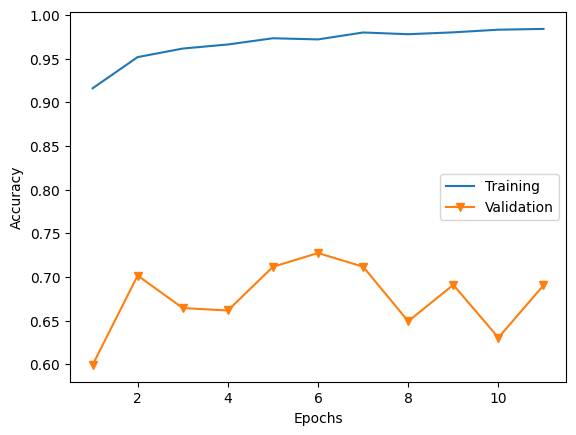

282/282 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8022    0.7870    0.7945      1000
           1     0.9462    0.8970    0.9209      1000
           2     0.8255    0.5250    0.6418      1000
           3     0.6119    0.5060    0.5539      1000
           4     0.6046    0.7890    0.6846      1000
           5     0.5453    0.7290    0.6239      1000
           6     0.6744    0.8390    0.7478      1000
           7     0.9398    0.5310    0.6786      1000
           8     0.7753    0.8970    0.8317      1000

    accuracy                         0.7222      9000
   macro avg     0.7472    0.7222    0.7198      9000
weighted avg     0.7472    0.7222    0.7198      9000



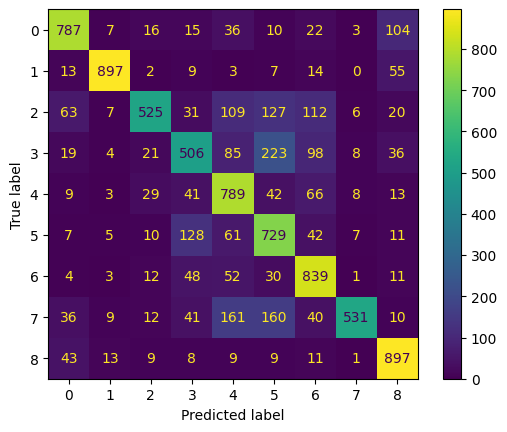

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


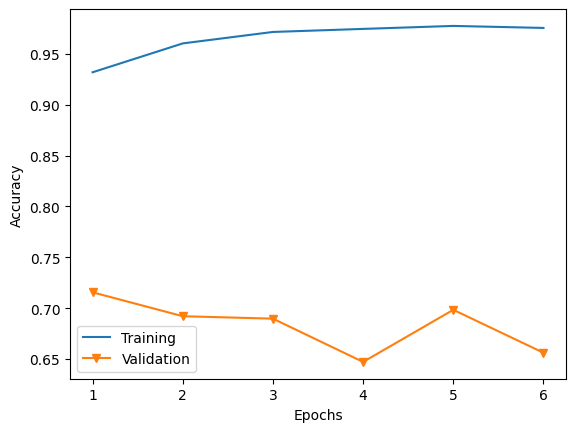

313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8392    0.7360    0.7842      1000
           1     0.9077    0.8060    0.8538      1000
           2     0.7122    0.6360    0.6719      1000
           3     0.5542    0.5570    0.5556      1000
           4     0.8857    0.5190    0.6545      1000
           5     0.4771    0.8130    0.6013      1000
           6     0.8324    0.7100    0.7663      1000
           7     0.6518    0.8200    0.7263      1000
           8     0.7612    0.8830    0.8176      1000
           9     0.8454    0.6560    0.7387      1000

    accuracy                         0.7136     10000
   macro avg     0.7467    0.7136    0.7170     10000
weighted avg     0.7467    0.7136    0.7170     10000



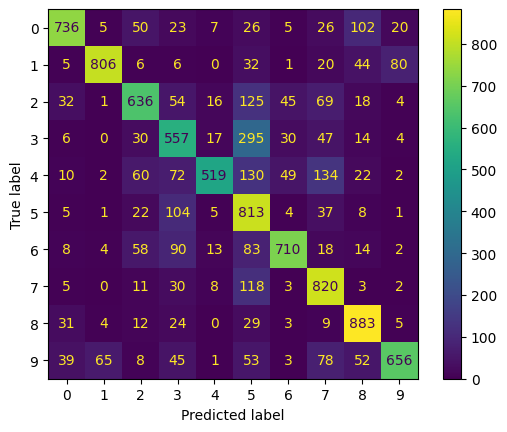

---------------------------------------------------------------------------



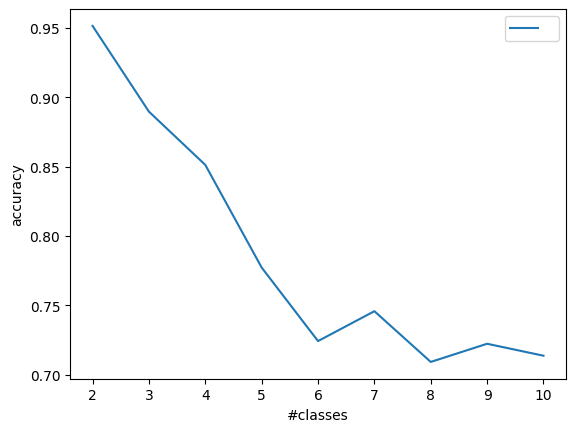

In [6]:
acc_list3 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    keep_same_model=True, 
    remove_prev_classes=False, 
    tuned_model_path=TUNED_CNN_MODEL_PATH, 
    preprocess="min-max",
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


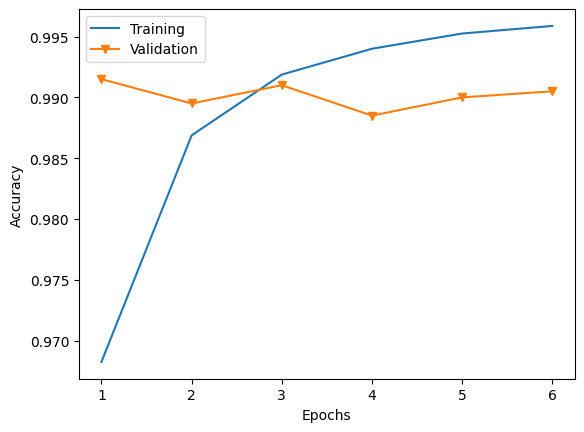

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9880    0.9860    0.9870      1000
           1     0.9860    0.9880    0.9870      1000

    accuracy                         0.9870      2000
   macro avg     0.9870    0.9870    0.9870      2000
weighted avg     0.9870    0.9870    0.9870      2000



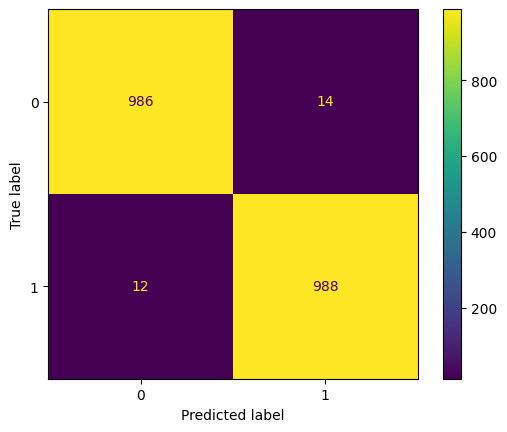

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


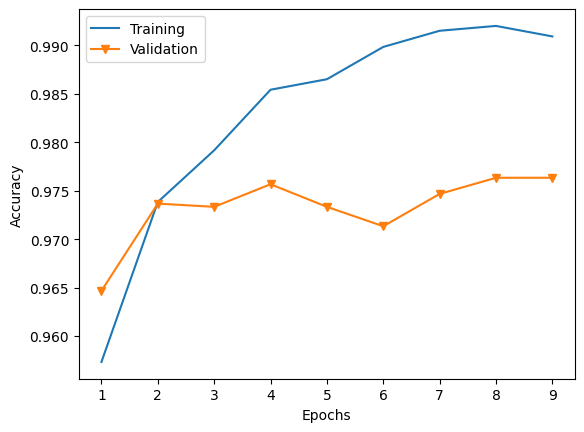

94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9698    0.9650    0.9674      1000
           1     0.9880    0.9880    0.9880      1000
           2     0.9761    0.9810    0.9786      1000

    accuracy                         0.9780      3000
   macro avg     0.9780    0.9780    0.9780      3000
weighted avg     0.9780    0.9780    0.9780      3000



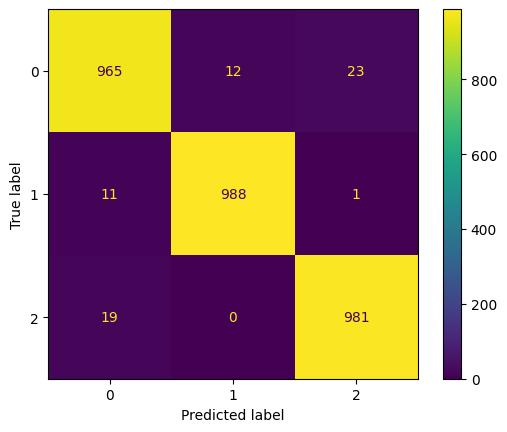

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


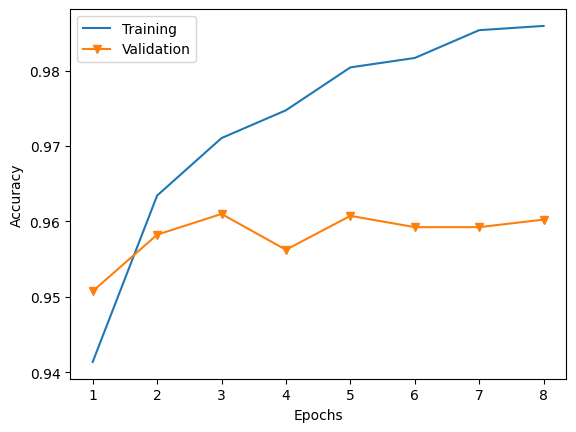

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9650    0.9650    0.9650      1000
           1     0.9831    0.9870    0.9850      1000
           2     0.9714    0.8820    0.9245      1000
           3     0.8888    0.9670    0.9262      1000

    accuracy                         0.9503      4000
   macro avg     0.9521    0.9503    0.9502      4000
weighted avg     0.9521    0.9503    0.9502      4000



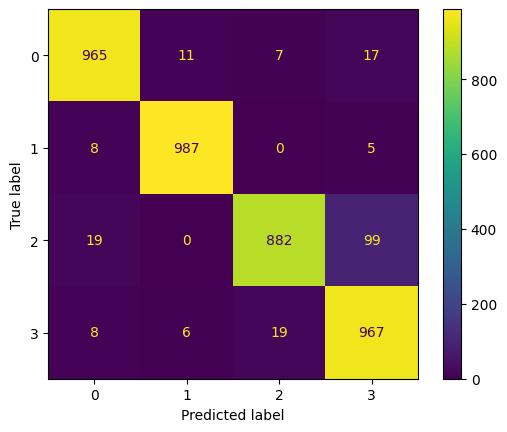

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


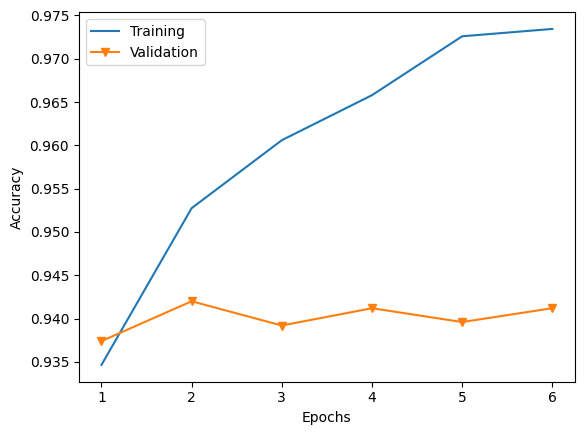

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9590    0.9590    0.9590      1000
           1     0.9830    0.9850    0.9840      1000
           2     0.9524    0.8600    0.9038      1000
           3     0.8956    0.9350    0.9149      1000
           4     0.8963    0.9420    0.9186      1000

    accuracy                         0.9362      5000
   macro avg     0.9373    0.9362    0.9361      5000
weighted avg     0.9373    0.9362    0.9361      5000



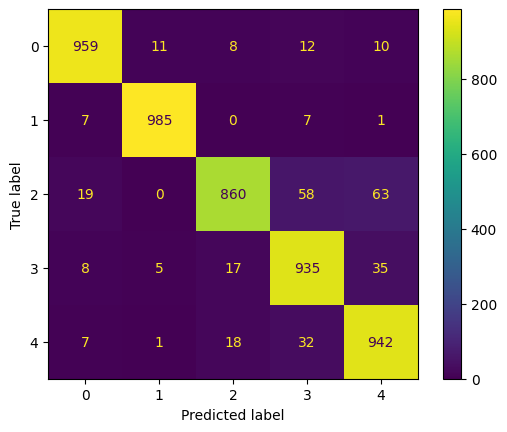

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


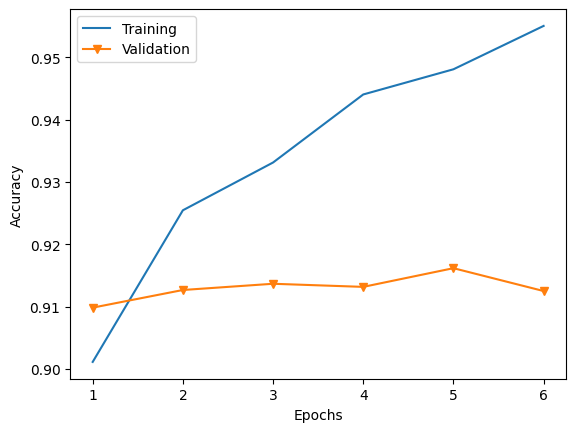

188/188 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9617    0.9530    0.9573      1000
           1     0.9909    0.9800    0.9854      1000
           2     0.9301    0.8650    0.8964      1000
           3     0.7923    0.8470    0.8188      1000
           4     0.8941    0.9200    0.9069      1000
           5     0.8589    0.8520    0.8554      1000

    accuracy                         0.9028      6000
   macro avg     0.9047    0.9028    0.9034      6000
weighted avg     0.9047    0.9028    0.9034      6000



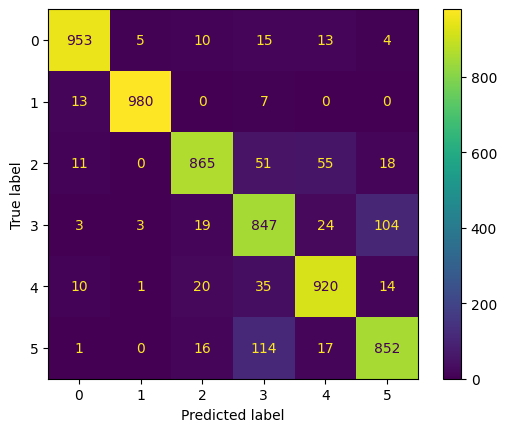

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


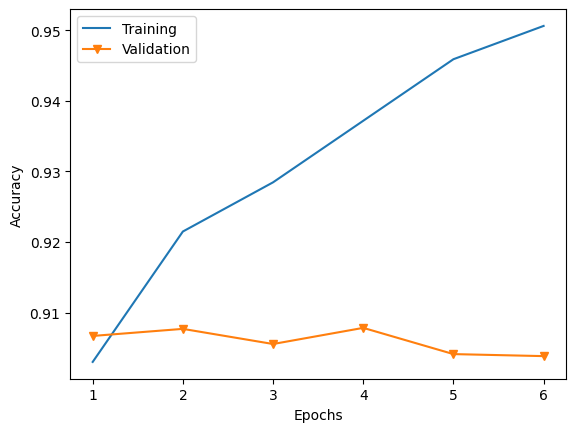

219/219 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9445    0.9530    0.9487      1000
           1     0.9889    0.9770    0.9829      1000
           2     0.9075    0.8440    0.8746      1000
           3     0.7873    0.8070    0.7970      1000
           4     0.8945    0.9070    0.9007      1000
           5     0.8638    0.8560    0.8599      1000
           6     0.8821    0.9200    0.9006      1000

    accuracy                         0.8949      7000
   macro avg     0.8955    0.8949    0.8949      7000
weighted avg     0.8955    0.8949    0.8949      7000



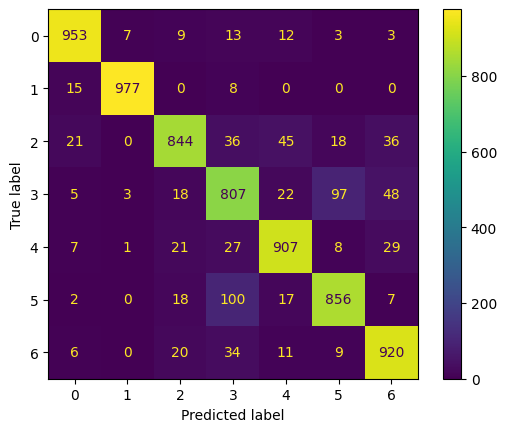

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


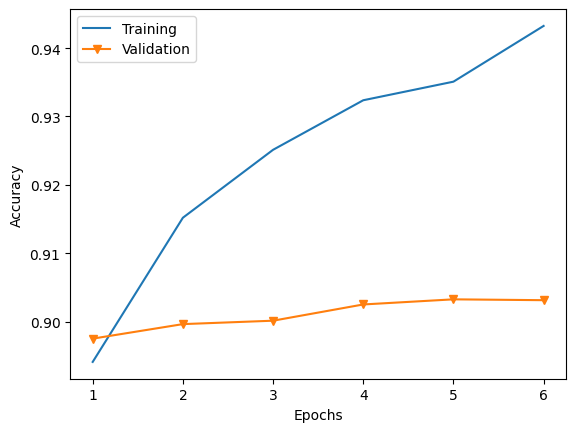

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9456    0.9390    0.9423      1000
           1     0.9899    0.9780    0.9839      1000
           2     0.9132    0.8520    0.8815      1000
           3     0.7902    0.8060    0.7980      1000
           4     0.8632    0.8900    0.8764      1000
           5     0.8563    0.8580    0.8571      1000
           6     0.9011    0.9020    0.9015      1000
           7     0.8905    0.9190    0.9045      1000

    accuracy                         0.8930      8000
   macro avg     0.8938    0.8930    0.8932      8000
weighted avg     0.8938    0.8930    0.8932      8000



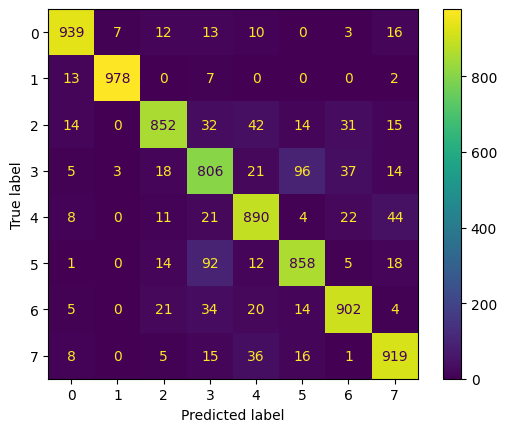

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


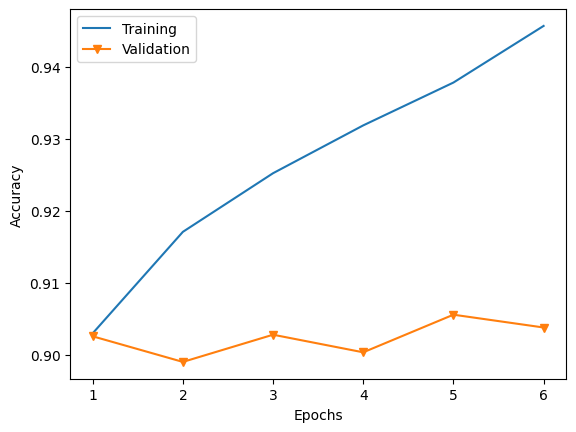

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9213    0.9020    0.9116      1000
           1     0.9848    0.9700    0.9773      1000
           2     0.9172    0.8420    0.8780      1000
           3     0.7900    0.8090    0.7994      1000
           4     0.8421    0.8960    0.8682      1000
           5     0.8609    0.8420    0.8514      1000
           6     0.9107    0.9080    0.9094      1000
           7     0.8829    0.9050    0.8938      1000
           8     0.9252    0.9530    0.9389      1000

    accuracy                         0.8919      9000
   macro avg     0.8928    0.8919    0.8920      9000
weighted avg     0.8928    0.8919    0.8920      9000



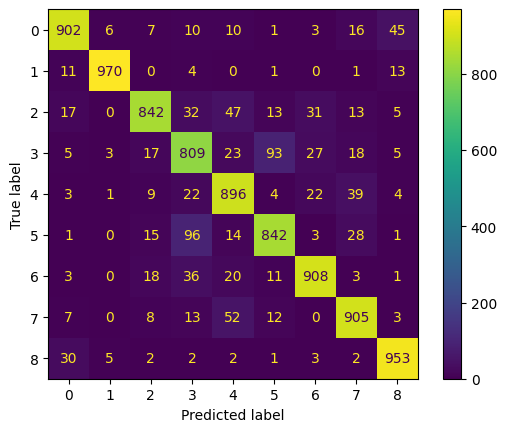

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


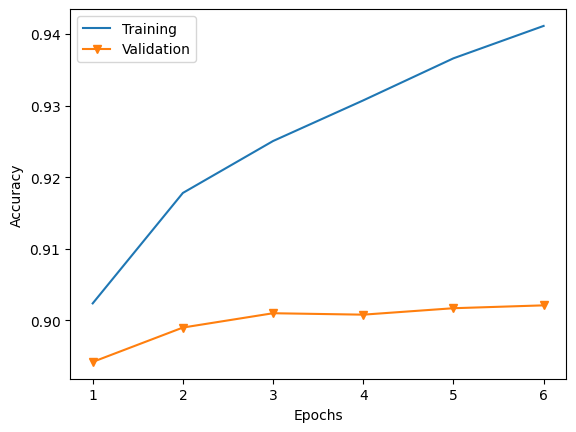

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9132    0.8940    0.9035      1000
           1     0.9621    0.8890    0.9241      1000
           2     0.9295    0.8310    0.8775      1000
           3     0.8091    0.7970    0.8030      1000
           4     0.8760    0.8690    0.8725      1000
           5     0.8425    0.8720    0.8570      1000
           6     0.8989    0.9160    0.9074      1000
           7     0.8887    0.9340    0.9108      1000
           8     0.9147    0.9440    0.9291      1000
           9     0.8650    0.9420    0.9019      1000

    accuracy                         0.8888     10000
   macro avg     0.8900    0.8888    0.8887     10000
weighted avg     0.8900    0.8888    0.8887     10000



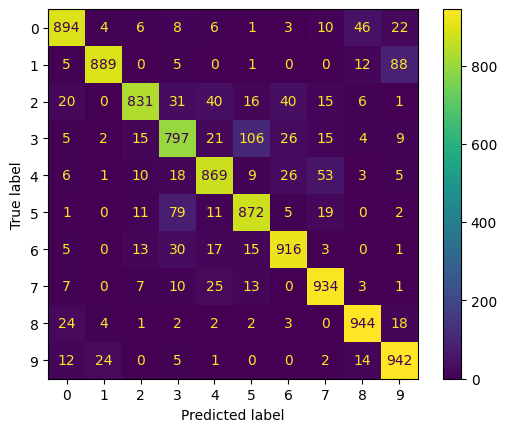

---------------------------------------------------------------------------



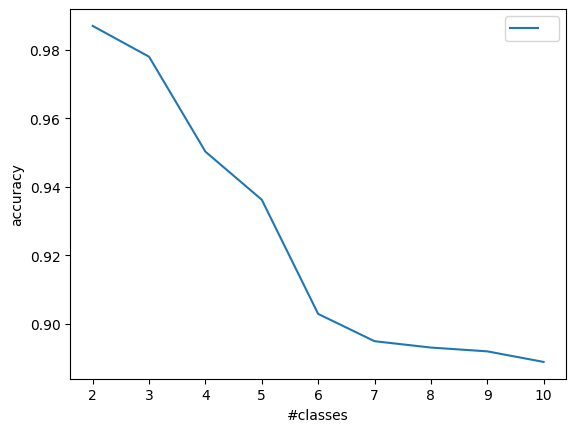

In [7]:
acc_list4 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    keep_same_model=True, 
    remove_prev_classes=False, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

## Continually adding classes to the same model without the previous data

### CNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 11.
Epoch 16: early stopping


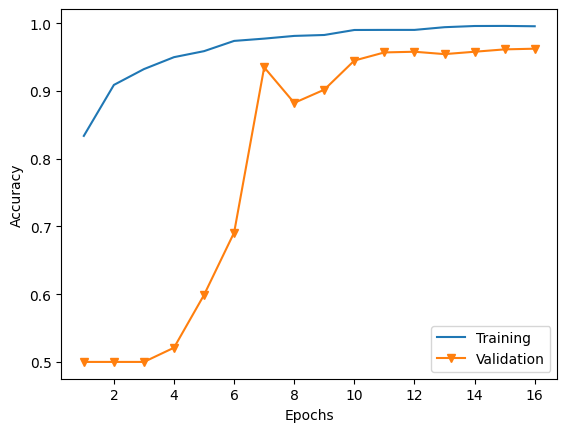

63/63 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.9686    0.9550    0.9617      1000
           1     0.9556    0.9690    0.9623      1000

    accuracy                         0.9620      2000
   macro avg     0.9621    0.9620    0.9620      2000
weighted avg     0.9621    0.9620    0.9620      2000



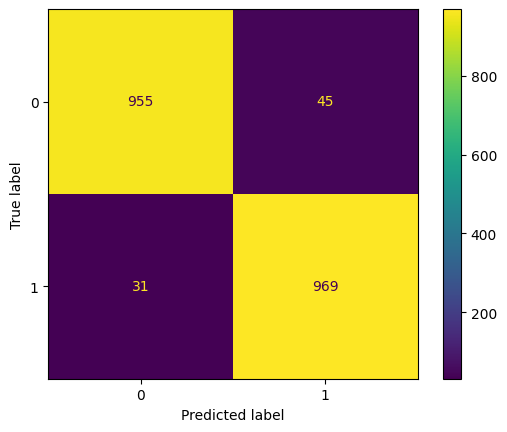

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


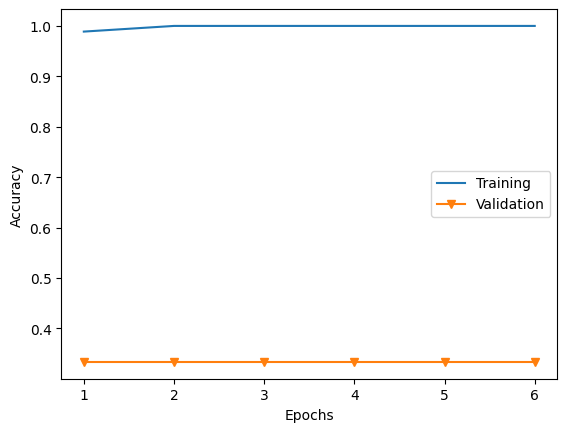

94/94 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.3333    1.0000    0.5000      1000

    accuracy                         0.3333      3000
   macro avg     0.1111    0.3333    0.1667      3000
weighted avg     0.1111    0.3333    0.1667      3000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


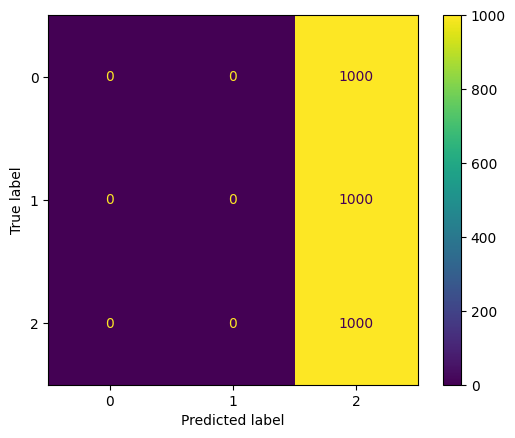

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


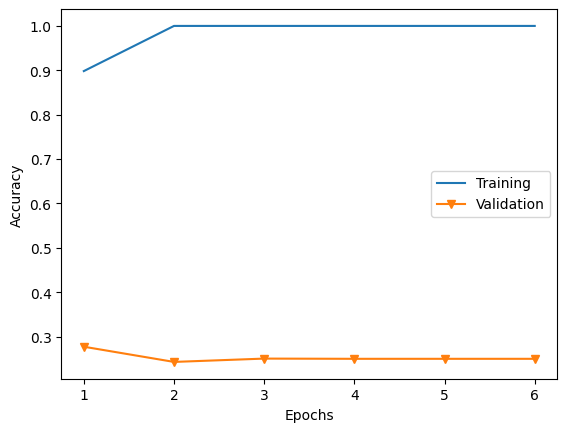

125/125 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.2557    0.8480    0.3930      1000
           3     0.3904    0.2670    0.3171      1000

    accuracy                         0.2787      4000
   macro avg     0.1615    0.2787    0.1775      4000
weighted avg     0.1615    0.2787    0.1775      4000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


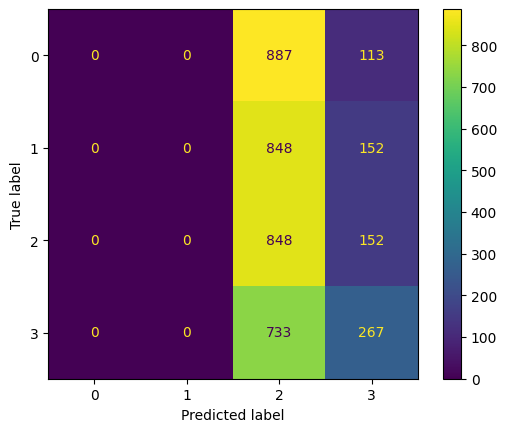

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


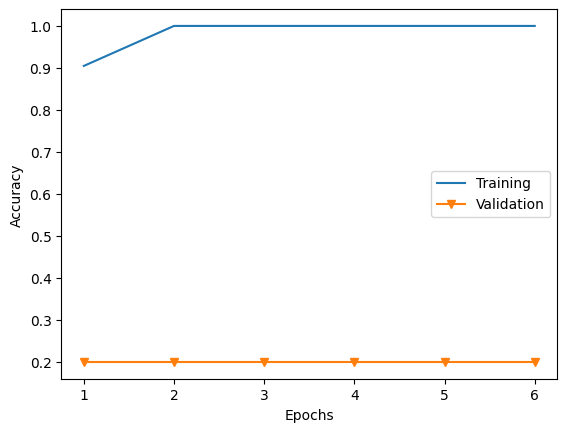

157/157 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.2000    1.0000    0.3333      1000

    accuracy                         0.2000      5000
   macro avg     0.0400    0.2000    0.0667      5000
weighted avg     0.0400    0.2000    0.0667      5000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


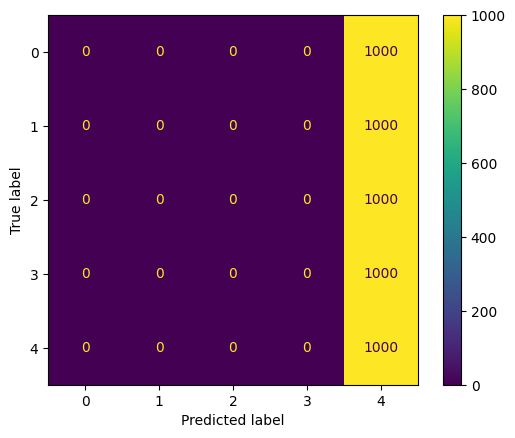

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


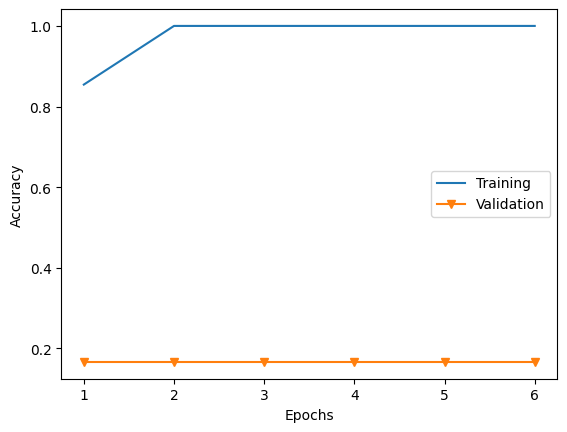

188/188 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.1667    1.0000    0.2857      1000

    accuracy                         0.1667      6000
   macro avg     0.0278    0.1667    0.0476      6000
weighted avg     0.0278    0.1667    0.0476      6000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


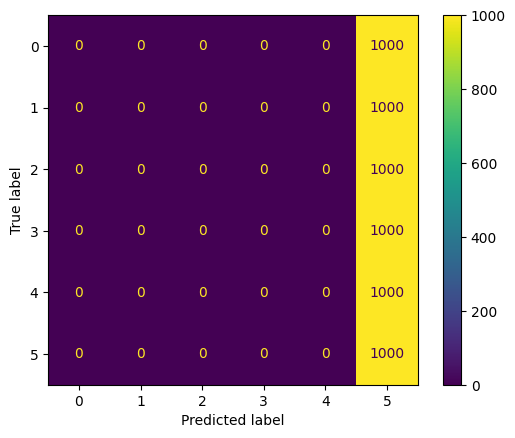

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


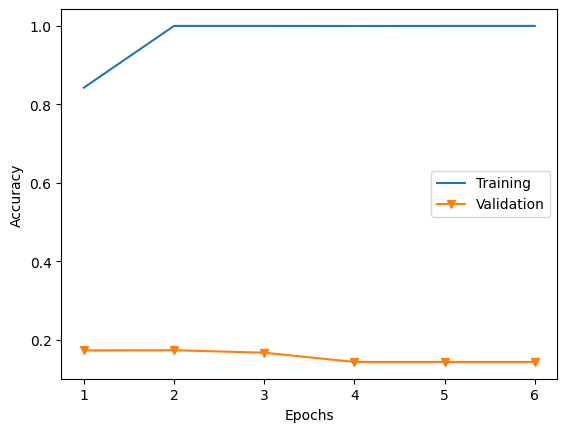

219/219 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.1939    0.4950    0.2786      1000
           6     0.1484    0.6600    0.2423      1000

    accuracy                         0.1650      7000
   macro avg     0.0489    0.1650    0.0744      7000
weighted avg     0.0489    0.1650    0.0744      7000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


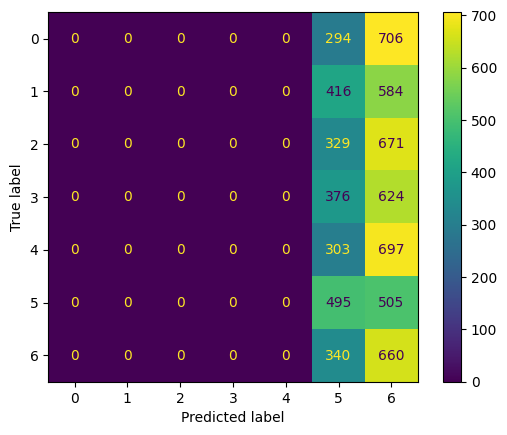

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


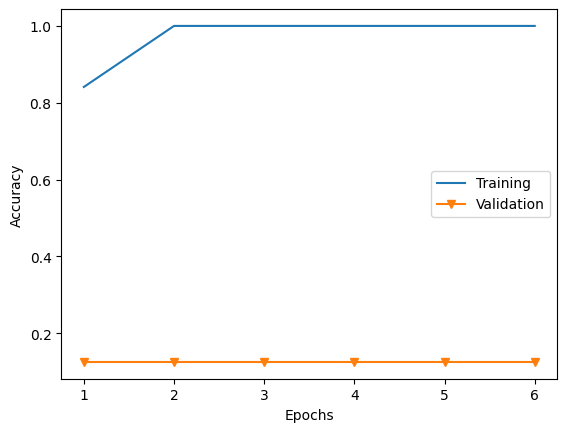

250/250 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.0000    0.0000    0.0000      1000
           7     0.1253    0.9990    0.2227      1000

    accuracy                         0.1249      8000
   macro avg     0.0157    0.1249    0.0278      8000
weighted avg     0.0157    0.1249    0.0278      8000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


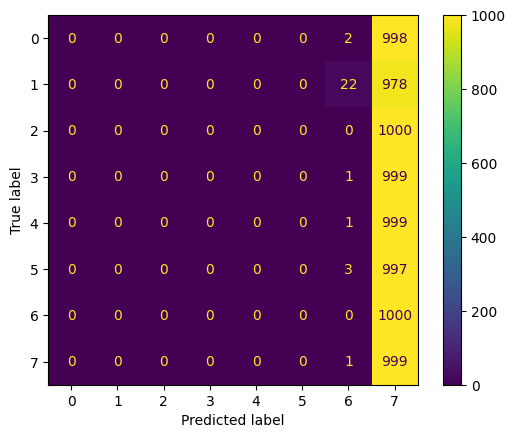

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


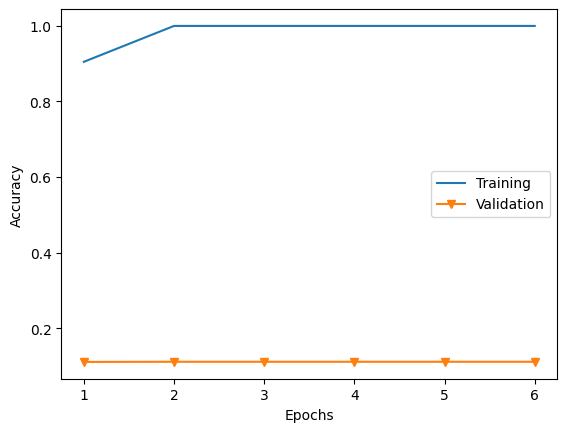

282/282 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.0000    0.0000    0.0000      1000
           7     0.1728    0.0140    0.0259      1000
           8     0.1111    0.9910    0.1998      1000

    accuracy                         0.1117      9000
   macro avg     0.0316    0.1117    0.0251      9000
weighted avg     0.0316    0.1117    0.0251      9000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


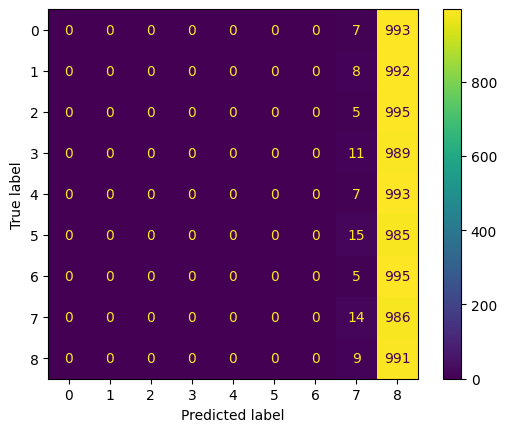

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


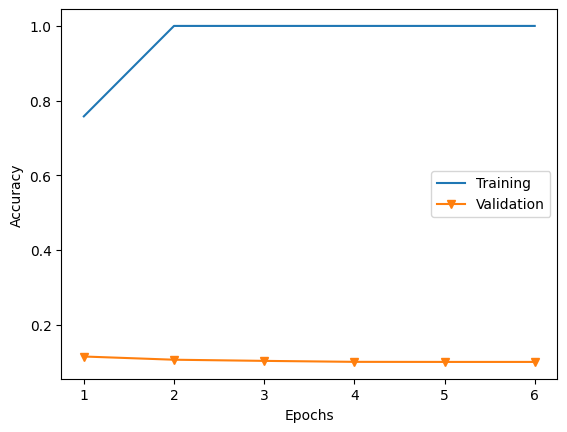

313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.0000    0.0000    0.0000      1000
           7     0.0000    0.0000    0.0000      1000
           8     0.0811    0.2070    0.1166      1000
           9     0.1228    0.9150    0.2166      1000

    accuracy                         0.1122     10000
   macro avg     0.0204    0.1122    0.0333     10000
weighted avg     0.0204    0.1122    0.0333     10000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


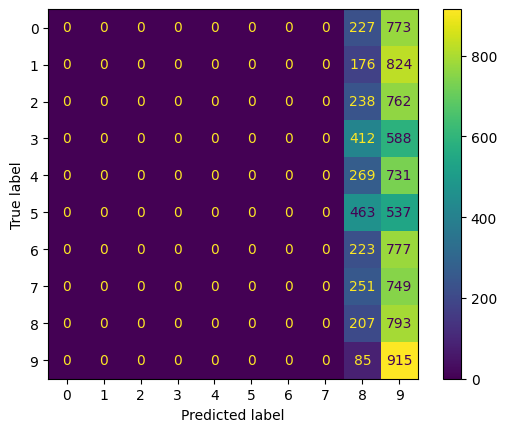

---------------------------------------------------------------------------



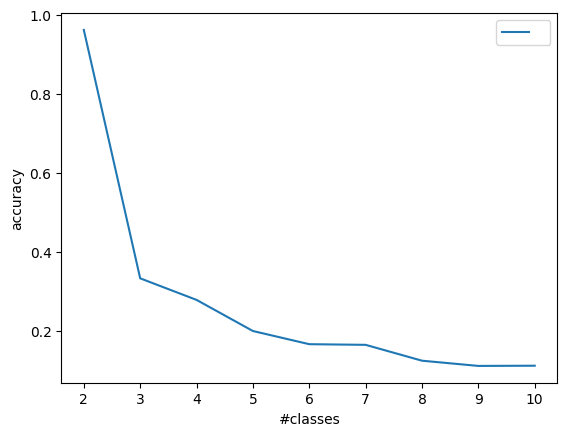

In [8]:
acc_list5 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    keep_same_model=True, 
    remove_prev_classes=True, 
    tuned_model_path=TUNED_CNN_MODEL_PATH, 
    preprocess="min-max",
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


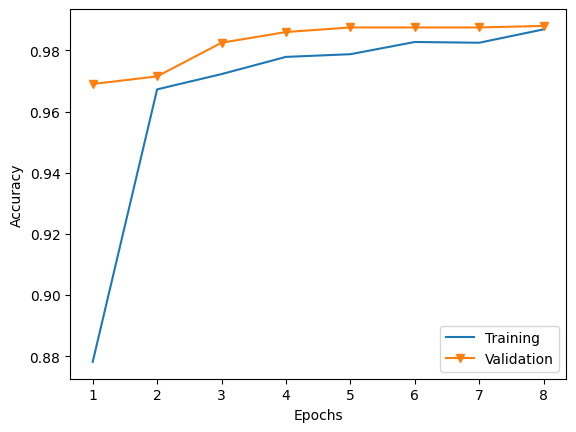

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9898    0.9700    0.9798      1000
           1     0.9706    0.9900    0.9802      1000

    accuracy                         0.9800      2000
   macro avg     0.9802    0.9800    0.9800      2000
weighted avg     0.9802    0.9800    0.9800      2000



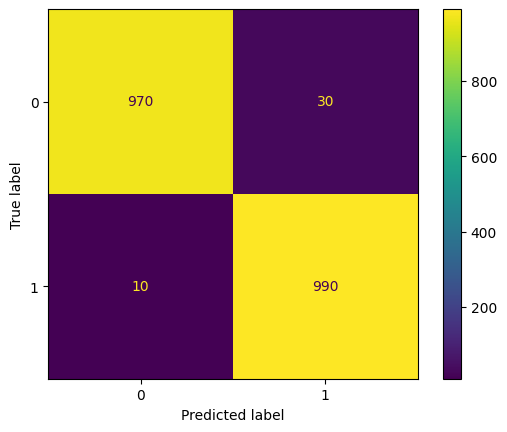

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 5.
Epoch 10: early stopping


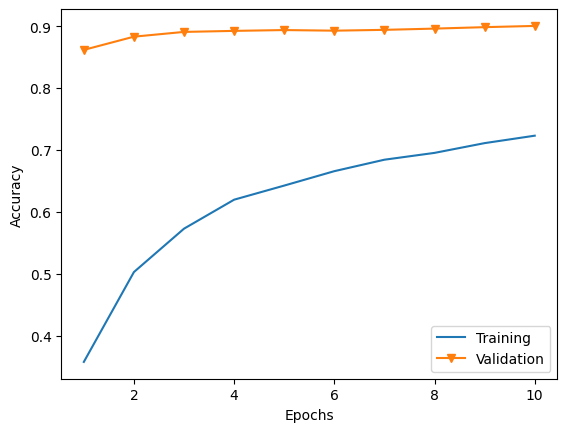

94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8344    0.9270    0.8783      1000
           1     0.9042    0.9820    0.9415      1000
           2     0.9639    0.7740    0.8586      1000

    accuracy                         0.8943      3000
   macro avg     0.9008    0.8943    0.8928      3000
weighted avg     0.9008    0.8943    0.8928      3000



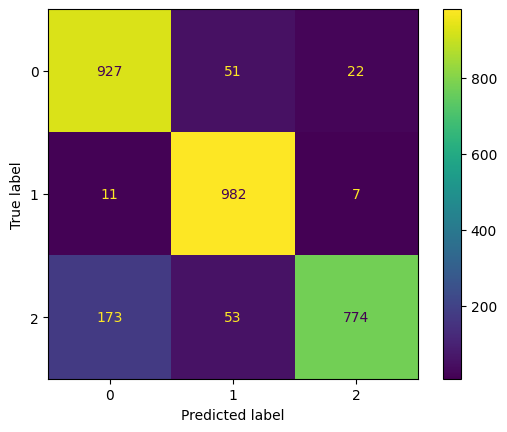

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


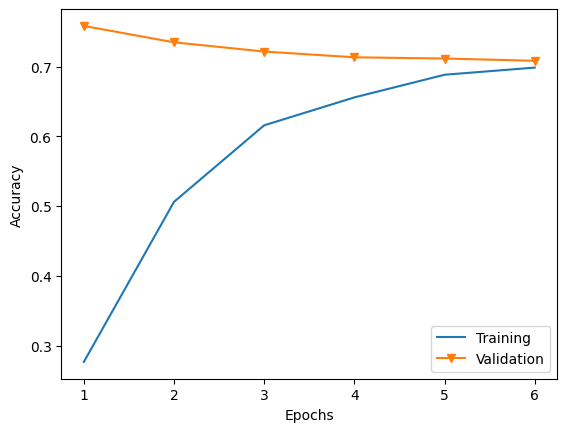

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.7687    0.9270    0.8404      1000
           1     0.8053    0.9640    0.8776      1000
           2     0.7539    0.5850    0.6588      1000
           3     0.6821    0.5600    0.6150      1000

    accuracy                         0.7590      4000
   macro avg     0.7525    0.7590    0.7480      4000
weighted avg     0.7525    0.7590    0.7480      4000



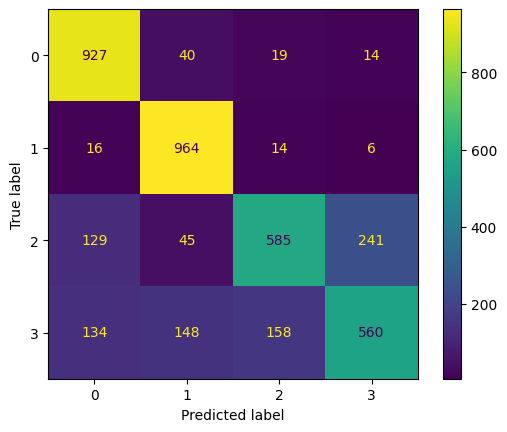

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


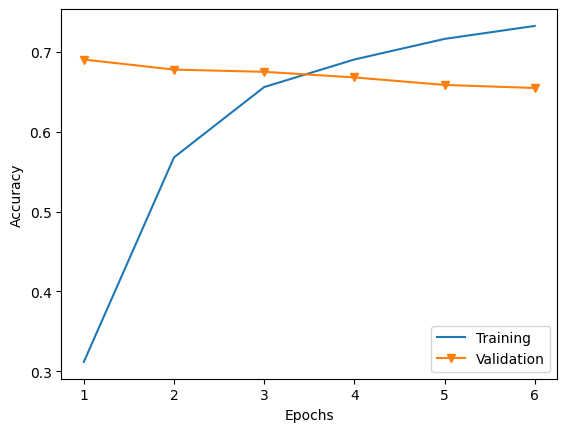

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8368    0.8000    0.8180      1000
           1     0.7010    0.9800    0.8173      1000
           2     0.5860    0.3270    0.4198      1000
           3     0.7972    0.5070    0.6198      1000
           4     0.5640    0.8190    0.6680      1000

    accuracy                         0.6866      5000
   macro avg     0.6970    0.6866    0.6686      5000
weighted avg     0.6970    0.6866    0.6686      5000



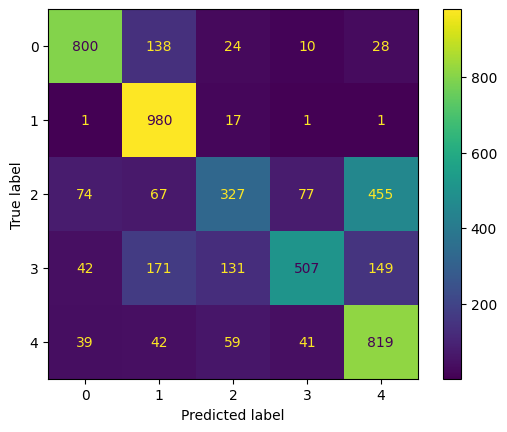

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


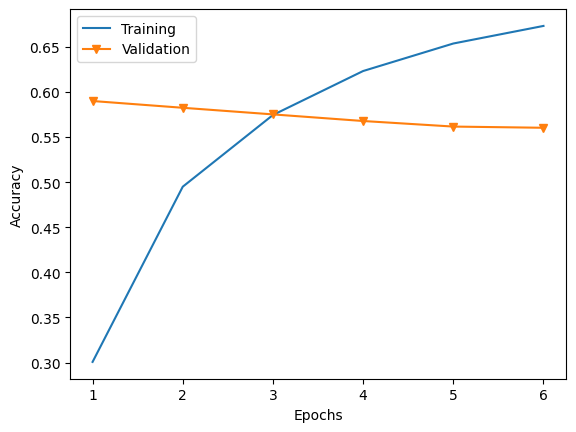

188/188 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8339    0.7630    0.7969      1000
           1     0.7215    0.9480    0.8194      1000
           2     0.4667    0.2660    0.3389      1000
           3     0.5200    0.1430    0.2243      1000
           4     0.5423    0.8340    0.6572      1000
           5     0.4575    0.6350    0.5318      1000

    accuracy                         0.5982      6000
   macro avg     0.5903    0.5982    0.5614      6000
weighted avg     0.5903    0.5982    0.5614      6000



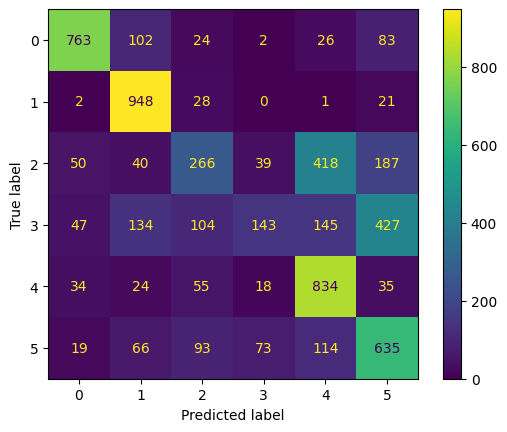

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


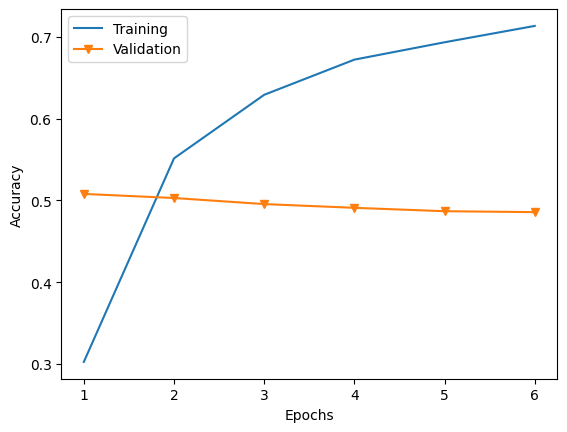

219/219 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8668    0.5920    0.7035      1000
           1     0.6572    0.9260    0.7688      1000
           2     0.3544    0.2300    0.2790      1000
           3     0.3747    0.1360    0.1996      1000
           4     0.4906    0.3900    0.4345      1000
           5     0.5313    0.5770    0.5532      1000
           6     0.3449    0.6950    0.4610      1000

    accuracy                         0.5066      7000
   macro avg     0.5171    0.5066    0.4857      7000
weighted avg     0.5171    0.5066    0.4857      7000



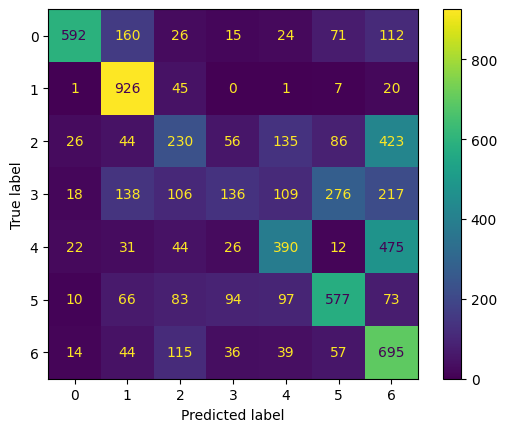

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


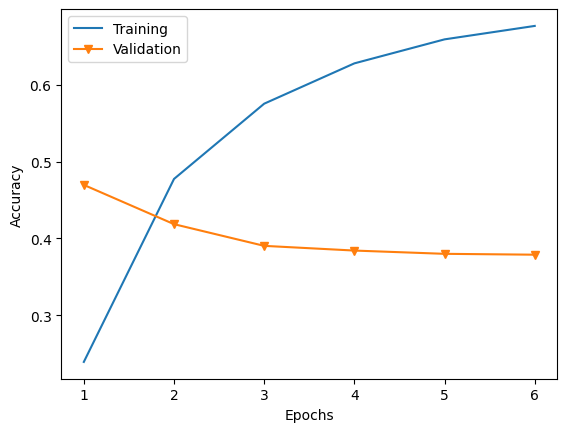

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8510    0.4340    0.5748      1000
           1     0.7467    0.8960    0.8145      1000
           2     0.2867    0.1620    0.2070      1000
           3     0.3577    0.0930    0.1476      1000
           4     0.4258    0.2180    0.2884      1000
           5     0.4929    0.5910    0.5375      1000
           6     0.3071    0.7180    0.4302      1000
           7     0.4739    0.6710    0.5555      1000

    accuracy                         0.4729      8000
   macro avg     0.4927    0.4729    0.4444      8000
weighted avg     0.4927    0.4729    0.4444      8000



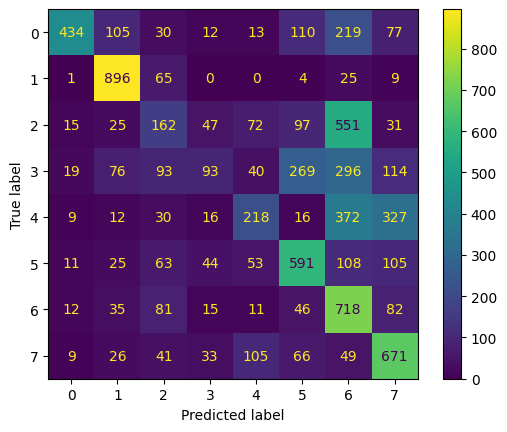

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


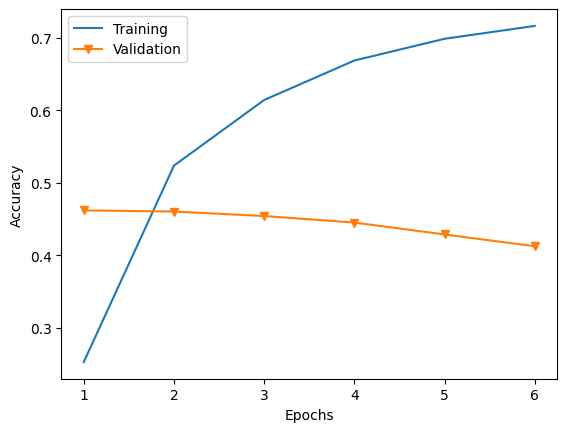

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.3435    0.0900    0.1426      1000
           1     0.8288    0.7650    0.7956      1000
           2     0.3738    0.1600    0.2241      1000
           3     0.3152    0.1100    0.1631      1000
           4     0.4682    0.2650    0.3384      1000
           5     0.5096    0.5560    0.5318      1000
           6     0.3560    0.7220    0.4769      1000
           7     0.4814    0.6590    0.5564      1000
           8     0.4405    0.8740    0.5858      1000

    accuracy                         0.4668      9000
   macro avg     0.4575    0.4668    0.4239      9000
weighted avg     0.4575    0.4668    0.4239      9000



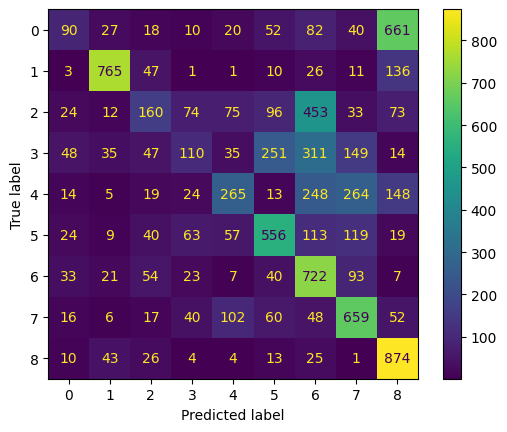

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


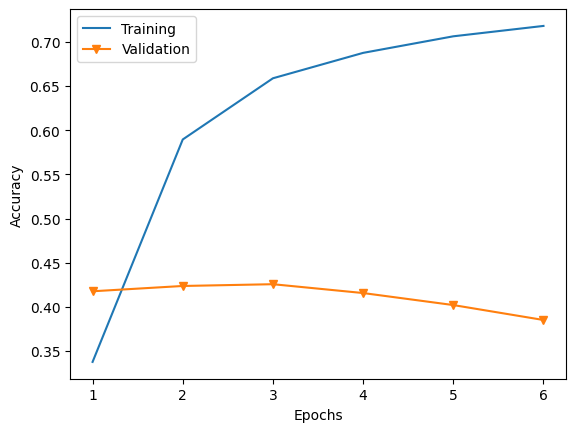

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.3184    0.1490    0.2030      1000
           1     0.6014    0.0830    0.1459      1000
           2     0.3772    0.1490    0.2136      1000
           3     0.2944    0.1590    0.2065      1000
           4     0.5660    0.2100    0.3063      1000
           5     0.5365    0.5150    0.5255      1000
           6     0.3344    0.6340    0.4378      1000
           7     0.5055    0.6390    0.5645      1000
           8     0.5012    0.8450    0.6292      1000
           9     0.3769    0.8600    0.5241      1000

    accuracy                         0.4243     10000
   macro avg     0.4412    0.4243    0.3756     10000
weighted avg     0.4412    0.4243    0.3756     10000



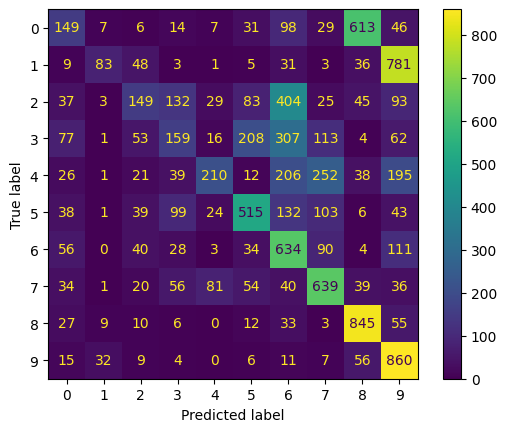

---------------------------------------------------------------------------



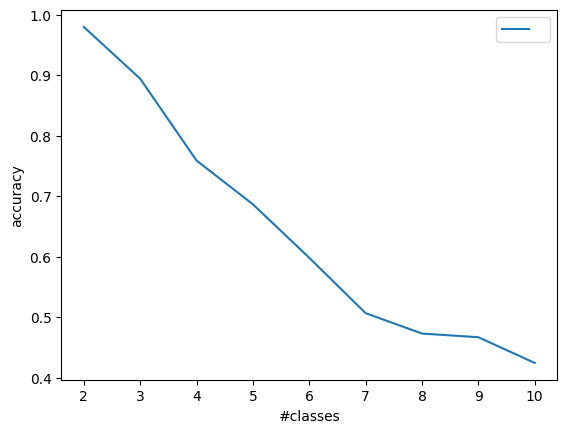

In [3]:
from tensorflow.keras import optimizers

from filtered_loss import FilteredLoss
from utils import get_compile_args


acc_list6 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    keep_same_model=True, 
    remove_prev_classes=True, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    onehot_labels=True,
    compile_args=get_compile_args(
        optimizer=optimizers.Adam(learning_rate=5e-5), 
        loss=FilteredLoss()
    ),
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS
)

## Conclusion

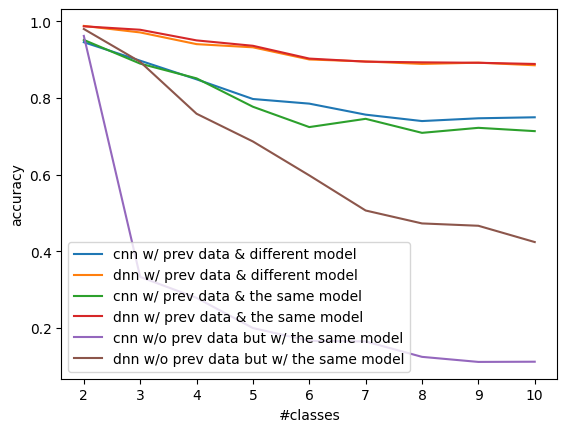

In [9]:
CL_plot(CLASS_NUM, 
    [
    (acc_list1, "cnn w/ prev data & different model"), 
    (acc_list2, "dnn w/ prev data & different model"), 
    (acc_list3, "cnn w/ prev data & the same model"), 
    (acc_list4, "dnn w/ prev data & the same model"), 
    (acc_list5, "cnn w/o prev data but w/ the same model"), 
    (acc_list6, "dnn w/o prev data but w/ the same model"), 
    ]
)